# AAI-590 Capstone Project - Context Aware Nutritional Assessment
## Predicting Food Processing Tiers through Machine Learning

## Team Members:
 - Jamshed Nabizada
 - Swapnil Patil

### Exploratory Data Analysis

In [26]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries and Configuration

In [27]:
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

from src.eda import (
    COMPARE_COLS,
    DEFAULT_LIGHT_DATASET_PATH,
    FULL_DATASET_PATH,
    GRADE_ORDER,
    NOVA_ORDER,
    OpenFoodFactsEDADataLoader,
    OpenFoodFactsEDAPlotter,
    cap_outliers,
    compute_high_correlation_pairs,
    compute_kruskal_summary,
    impute_with_global_median,
    print_dataset_overview,
)

loader = OpenFoodFactsEDADataLoader()
plotter = OpenFoodFactsEDAPlotter()
DATASET_PATH = DEFAULT_LIGHT_DATASET_PATH

## 2. Load and Inspect Dataset

In [28]:
dataset = loader.load(DATASET_PATH)
df = dataset.df
NUTRIENT_COLS = dataset.nutrient_cols
META_COLS = dataset.meta_cols

print_dataset_overview(dataset)
df.head(3)

Detected delimiter: COMMA
Dataset path: dataset\light.csv
Shape: (149373, 21)
Loaded columns (21): ['additives_n', 'additives_tags', 'brands', 'carbohydrates_100g', 'categories_en', 'code', 'countries_en', 'energy_100g', 'fat_100g', 'fiber_100g', 'ingredients_text', 'nova_group', 'nutrition_grade_fr', 'pnns_groups_1', 'pnns_groups_2', 'product_name', 'proteins_100g', 'salt_100g', 'saturated-fat_100g', 'sodium_100g', 'sugars_100g']
Nutrient columns used in EDA (9): ['energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']

Nutri-Score distribution:
nutrition_grade_fr
a       16146
b       11314
c       30914
d       19582
e       14451
<NA>    56966
Name: count, dtype: Int64

NOVA distribution:
nova_group
1        8400
2        1090
3       15904
4       57680
<NA>    66299
Name: count, dtype: Int64


,code,product_name,brands,categories_en,countries_en,pnns_groups_1,pnns_groups_2,nutrition_grade_fr,nova_group,additives_n,additives_tags,ingredients_text,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,101348123,Focaccia Tomat,La Lorraine,NaN,Sweden,unknown,unknown,<NA>,<NA>,NaN,NaN,NaN,1058.600,2.100,0.500,50.000,3.000,NaN,7.700,1.867,0.747
1,103783001,greek yogurt,Chobani,"Dairies,Fermented foods,Fermented milk product...",United States,Milk and dairy products,Milk and yogurt,<NA>,<NA>,NaN,NaN,NaN,373.000,1.667,1.000,10.667,9.333,0.667,7.333,NaN,NaN
2,107972030,Fajita Chicken W/ Wholegrain Rice,Fuelhub,NaN,United Kingdom,unknown,unknown,<NA>,<NA>,NaN,NaN,NaN,399.030,1.050,NaN,10.297,NaN,NaN,10.891,NaN,NaN


In [29]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 149373 entries, 0 to 149374
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                149373 non-null  object 
 1   product_name        145836 non-null  object 
 2   brands              130897 non-null  object 
 3   categories_en       103011 non-null  object 
 4   countries_en        149164 non-null  object 
 5   pnns_groups_1       149373 non-null  object 
 6   pnns_groups_2       149373 non-null  object 
 7   nutrition_grade_fr  92407 non-null   string 
 8   nova_group          83074 non-null   Int64  
 9   additives_n         90640 non-null   float64
 10  additives_tags      52766 non-null   object 
 11  ingredients_text    90638 non-null   object 
 12  energy_100g         148993 non-null  float64
 13  fat_100g            148003 non-null  float64
 14  saturated-fat_100g  138147 non-null  float64
 15  carbohydrates_100g  147808 non-null  fl

In [30]:
df[NUTRIENT_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
energy_100g,148993.000,1126.530,4506.910,-575.000,436.900,1072.500,1626.000,1600000.000
fat_100g,148003.000,10.820,42.070,-0.880,1.470,5.000,14.990,10000.000
saturated-fat_100g,138147.000,3.960,28.510,-0.130,0.200,1.400,4.400,10000.000
carbohydrates_100g,147808.000,31.720,39.680,-0.110,6.400,22.500,54.000,7142.860
sugars_100g,140799.000,71033.890,26650184.150,-0.090,1.400,4.400,12.670,10000000000.000
fiber_100g,105668.000,98.240,30762.960,-0.280,0.340,2.000,4.700,10000000.000
proteins_100g,148096.000,6762.080,2598533.570,0.000,3.400,7.400,11.500,1000000000.000
salt_100g,137865.000,4.980,737.740,-0.180,0.100,0.550,1.220,250000.000
sodium_100g,137865.000,1.990,295.060,-0.070,0.040,0.220,0.490,100000.000


## 3. Data Quality Assessment

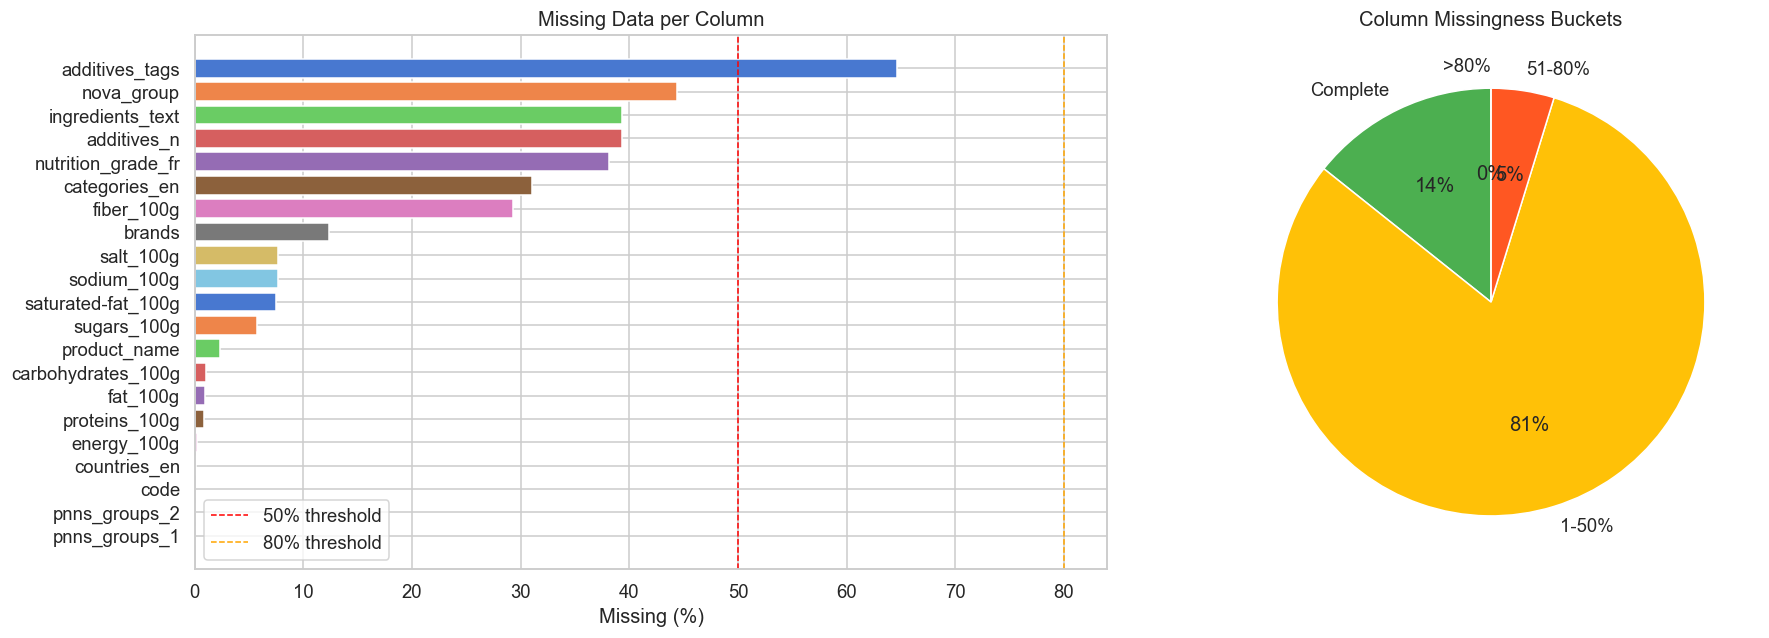

Duplicate rows       : 0
Columns >50% missing : 1
Columns >80% missing : 0


In [31]:
plotter.plot_missingness_overview(df)

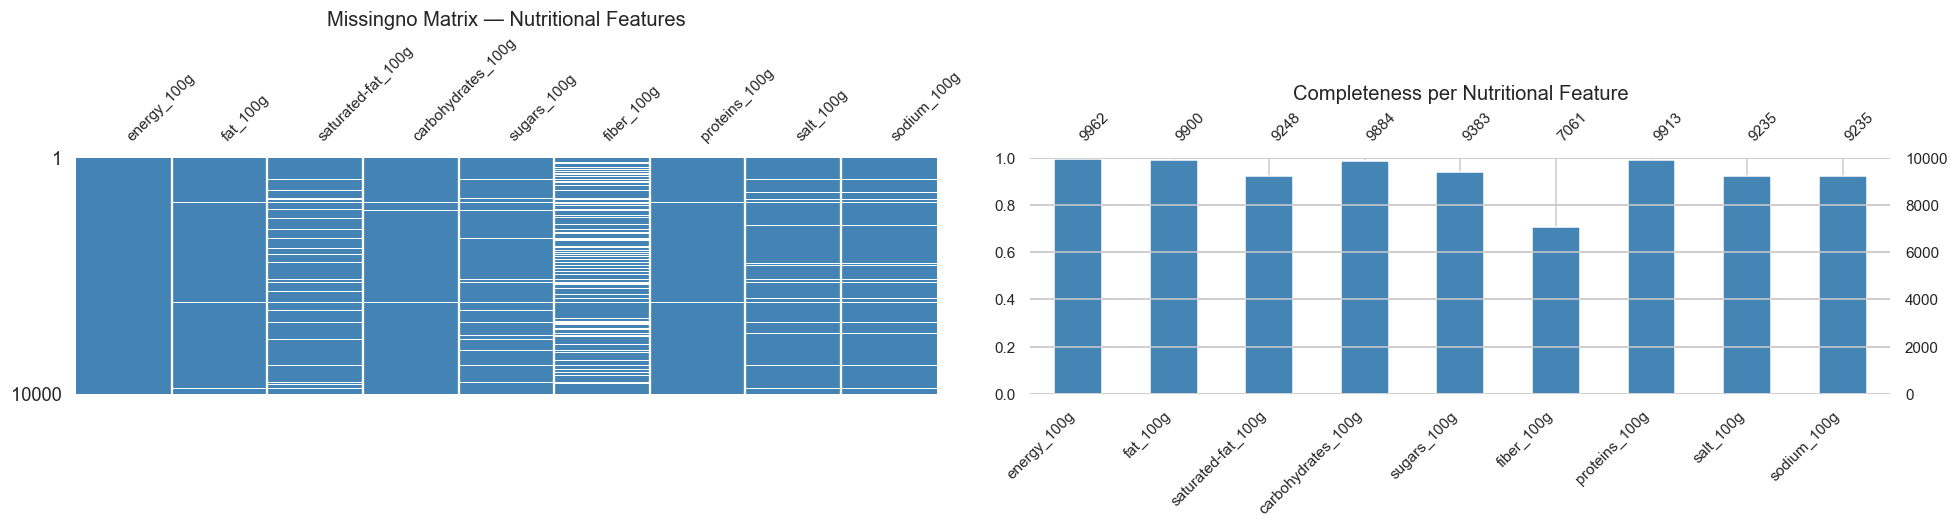

In [32]:
plotter.plot_missingno_matrix(df, NUTRIENT_COLS)

## 4. Target Variable Analysis: Nutritional Quality and Processing Level

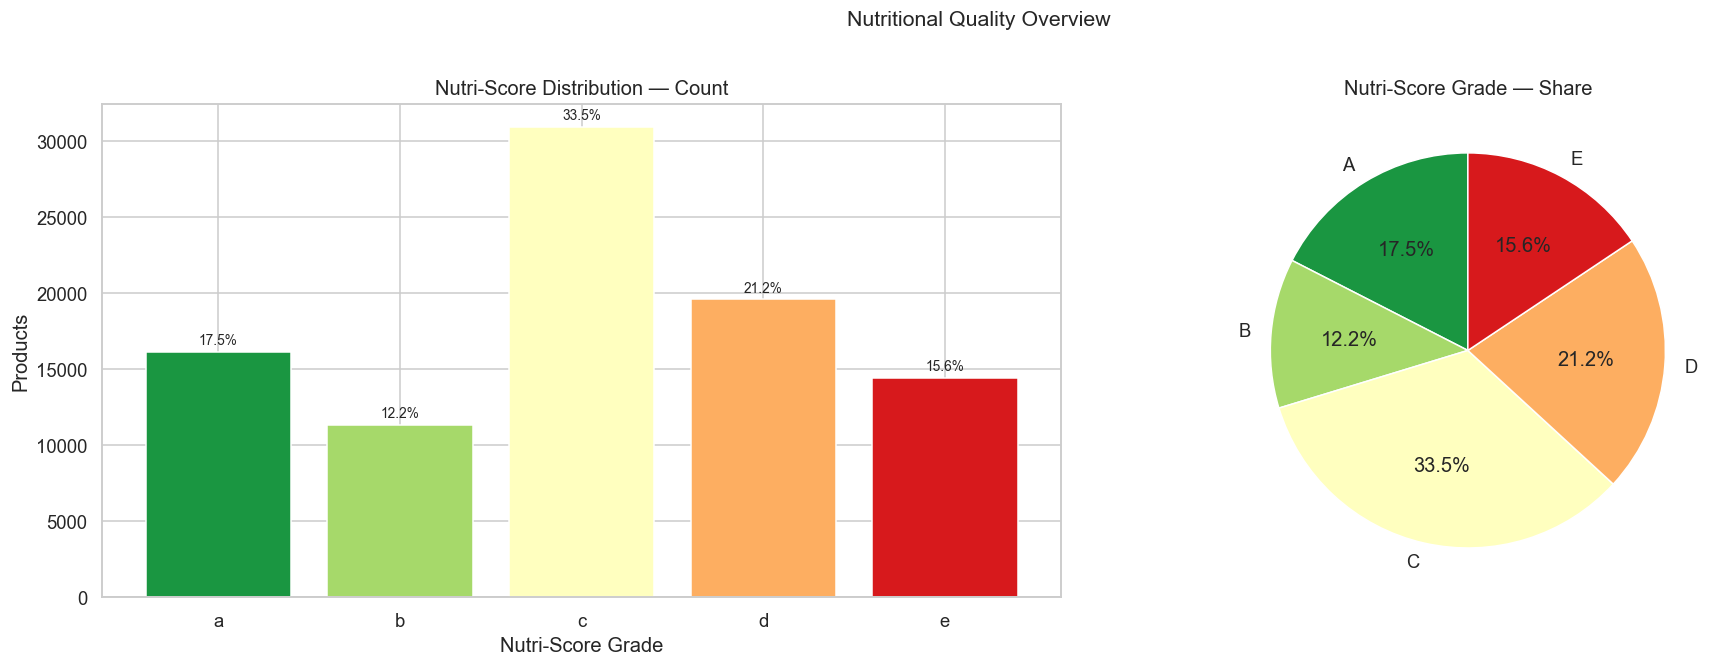

Nutri-Score coverage: 61.9% of loaded rows


In [33]:
plotter.plot_nutriscore_overview(df)

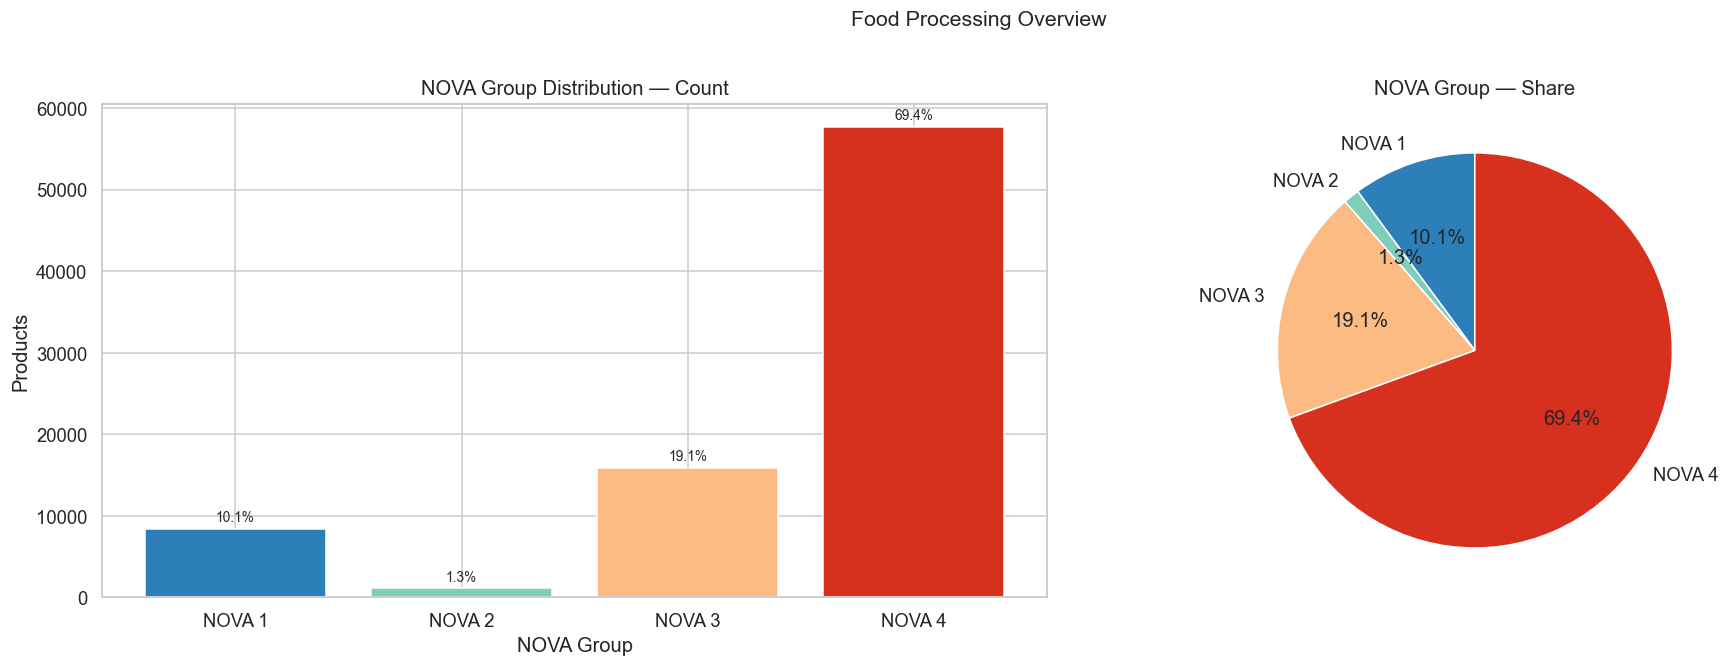

NOVA coverage: 55.6% of loaded rows


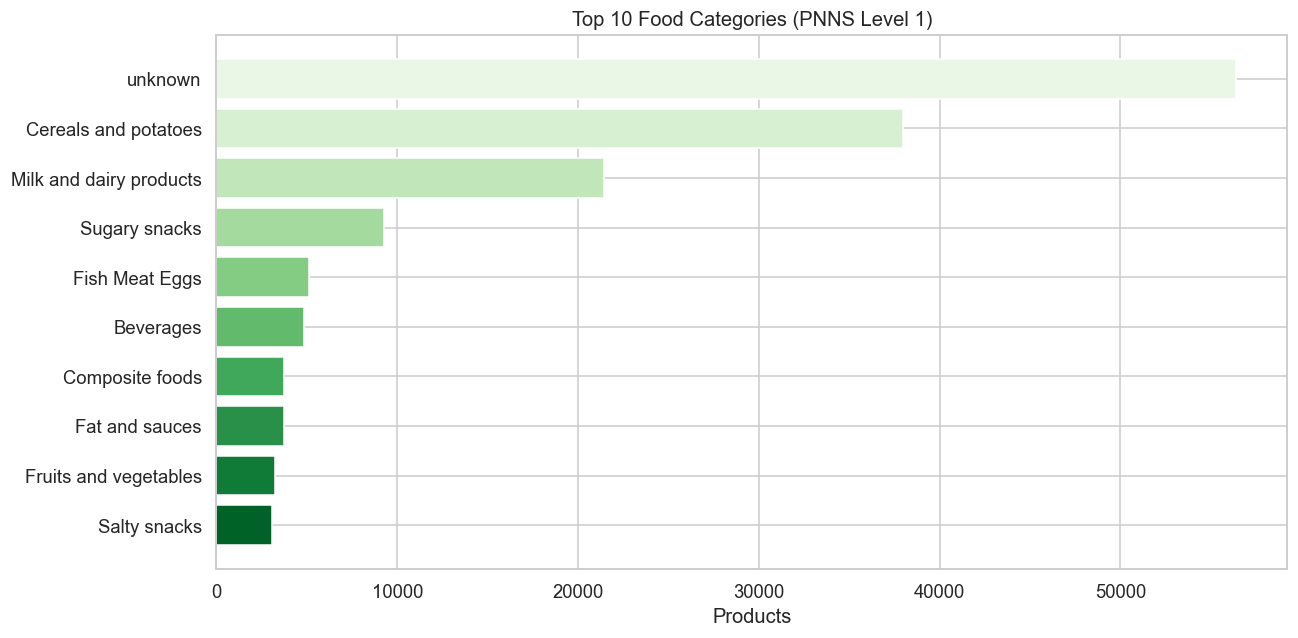

In [34]:
plotter.plot_nova_overview(df)
plotter.plot_category_overview(df)

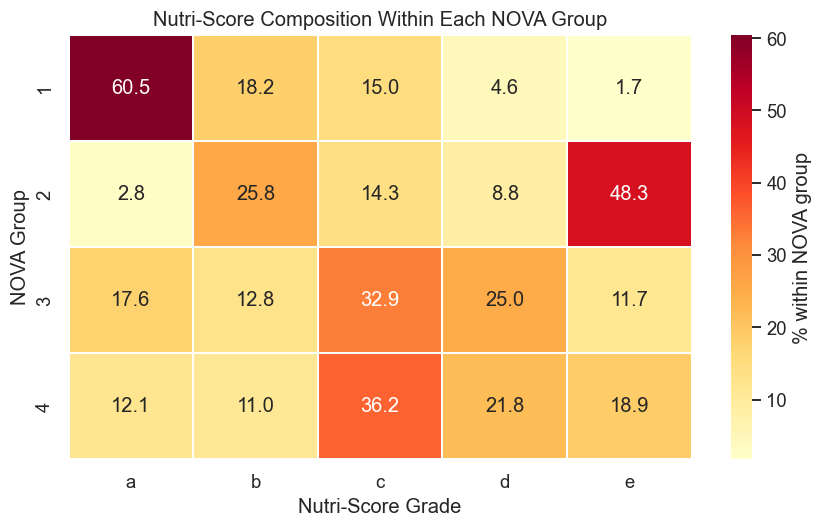

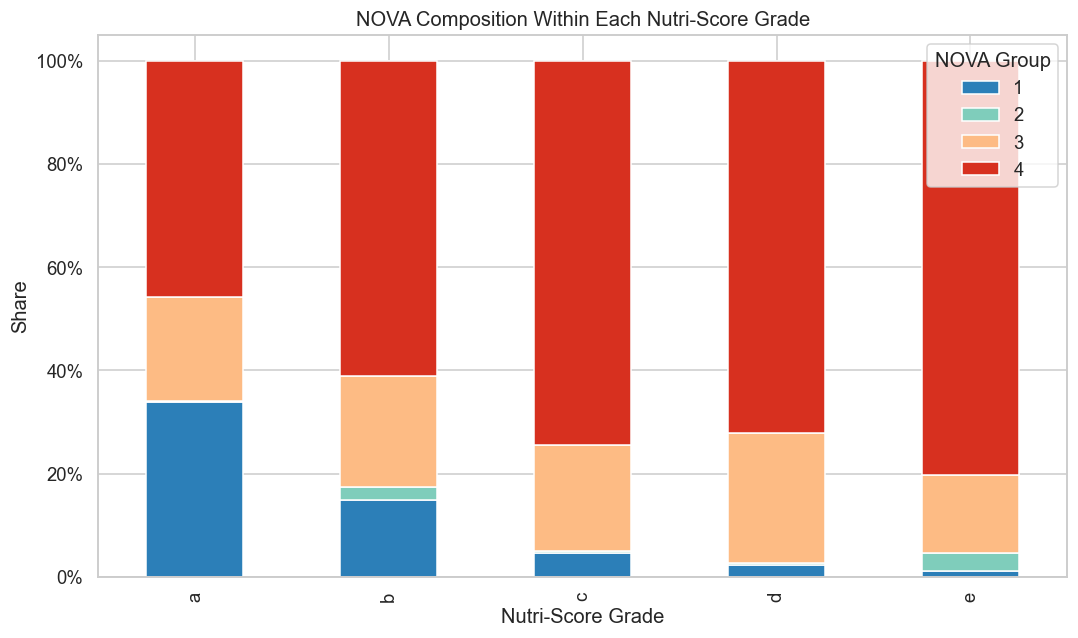

In [35]:
plotter.plot_nova_nutriscore_heatmap(df)
plotter.plot_nova_nutriscore_stacked_share(df)

## 5. Nutritional Feature Distributions

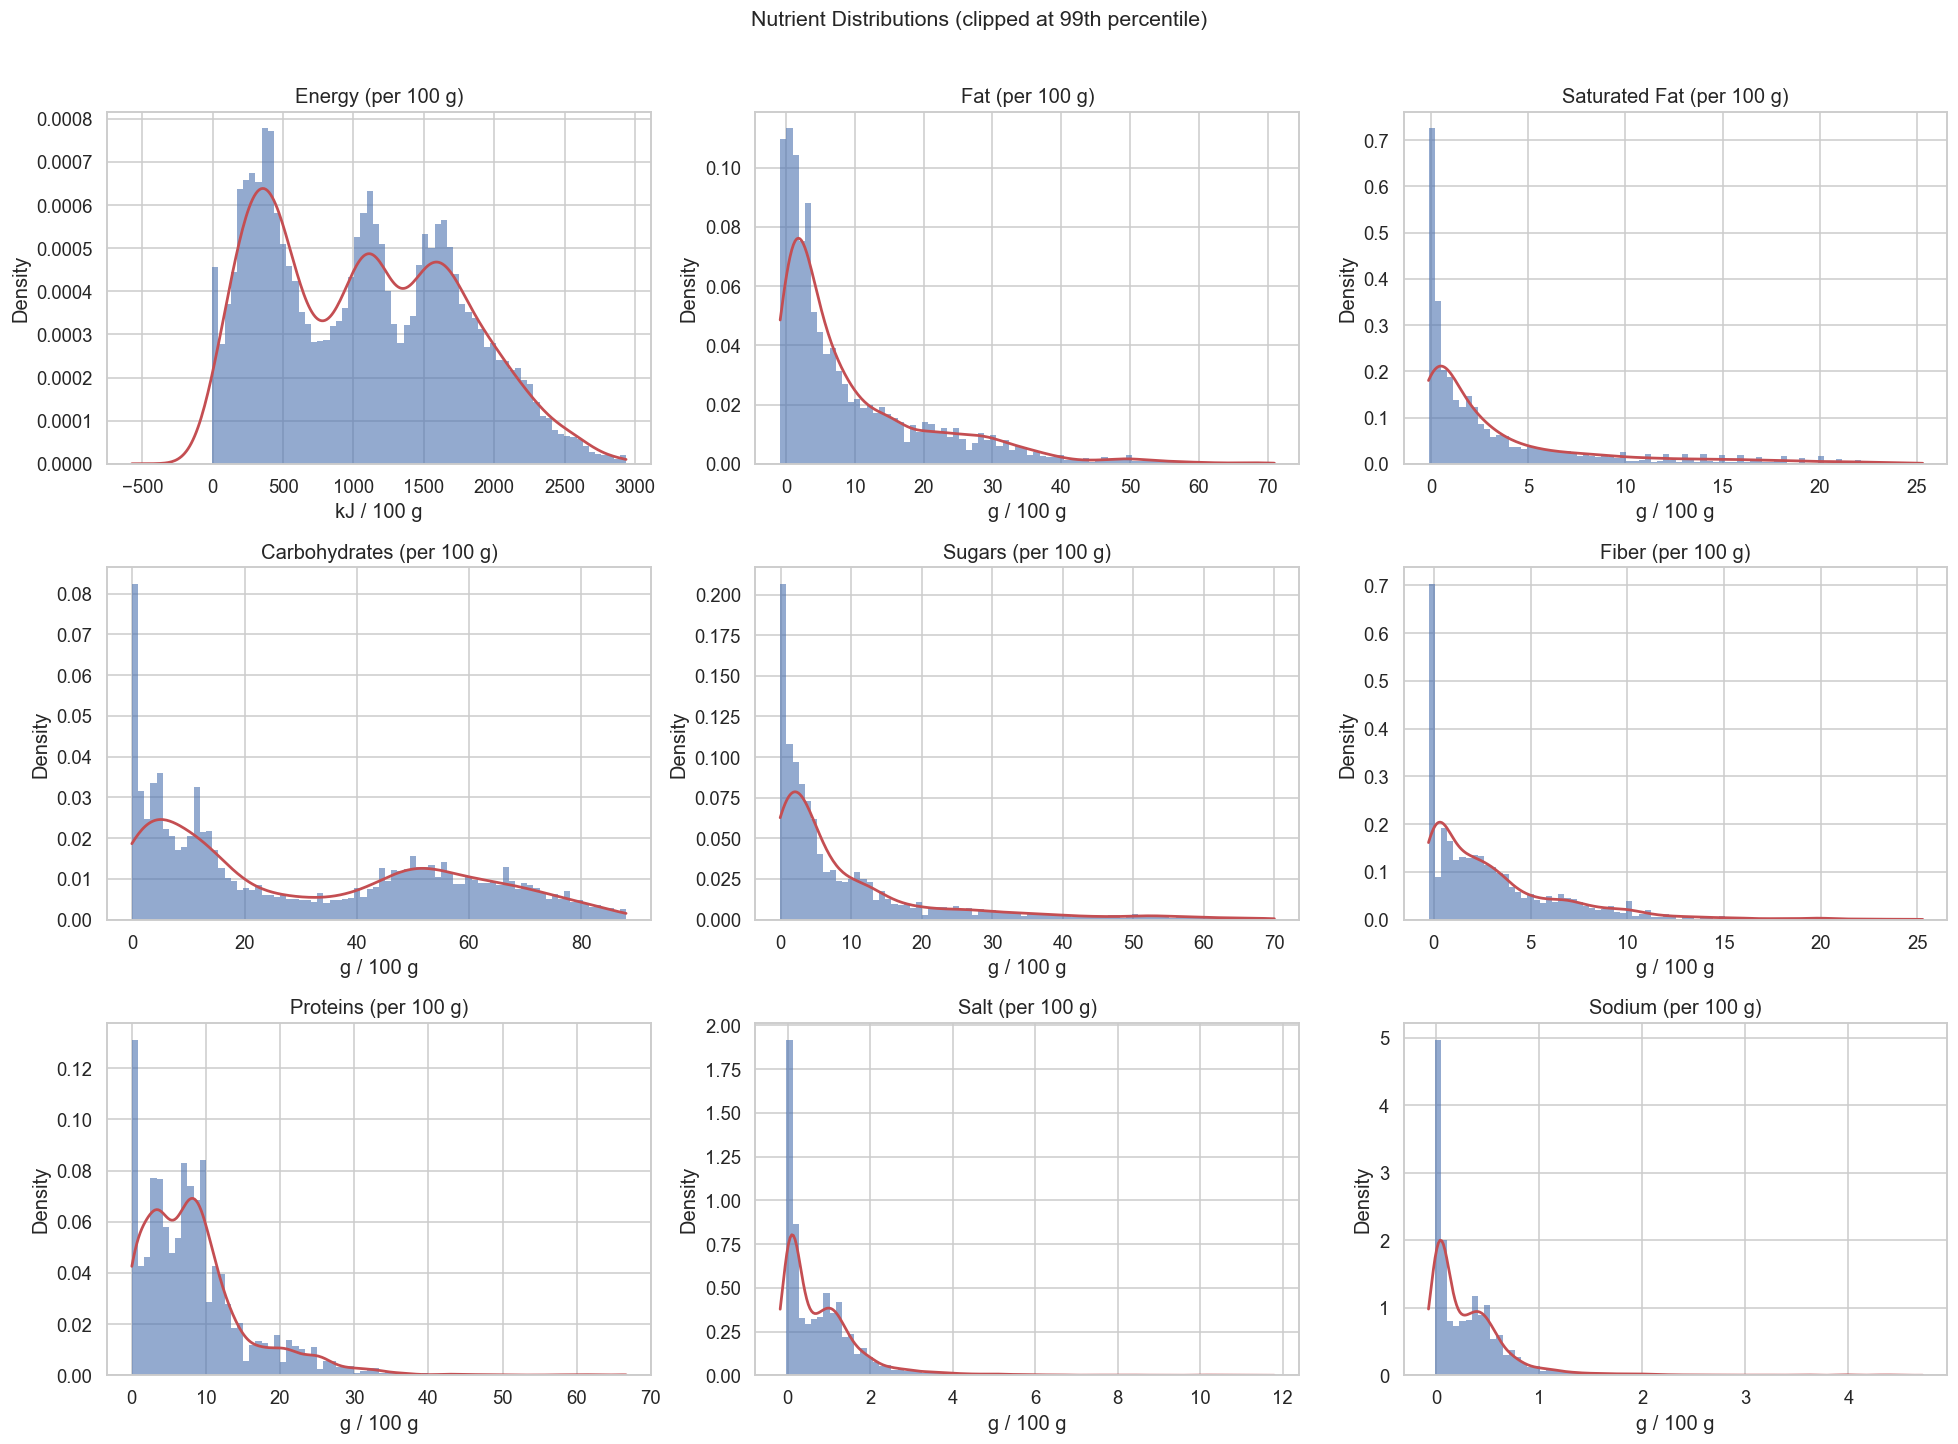

In [36]:
plotter.plot_nutrient_distributions(df, NUTRIENT_COLS)

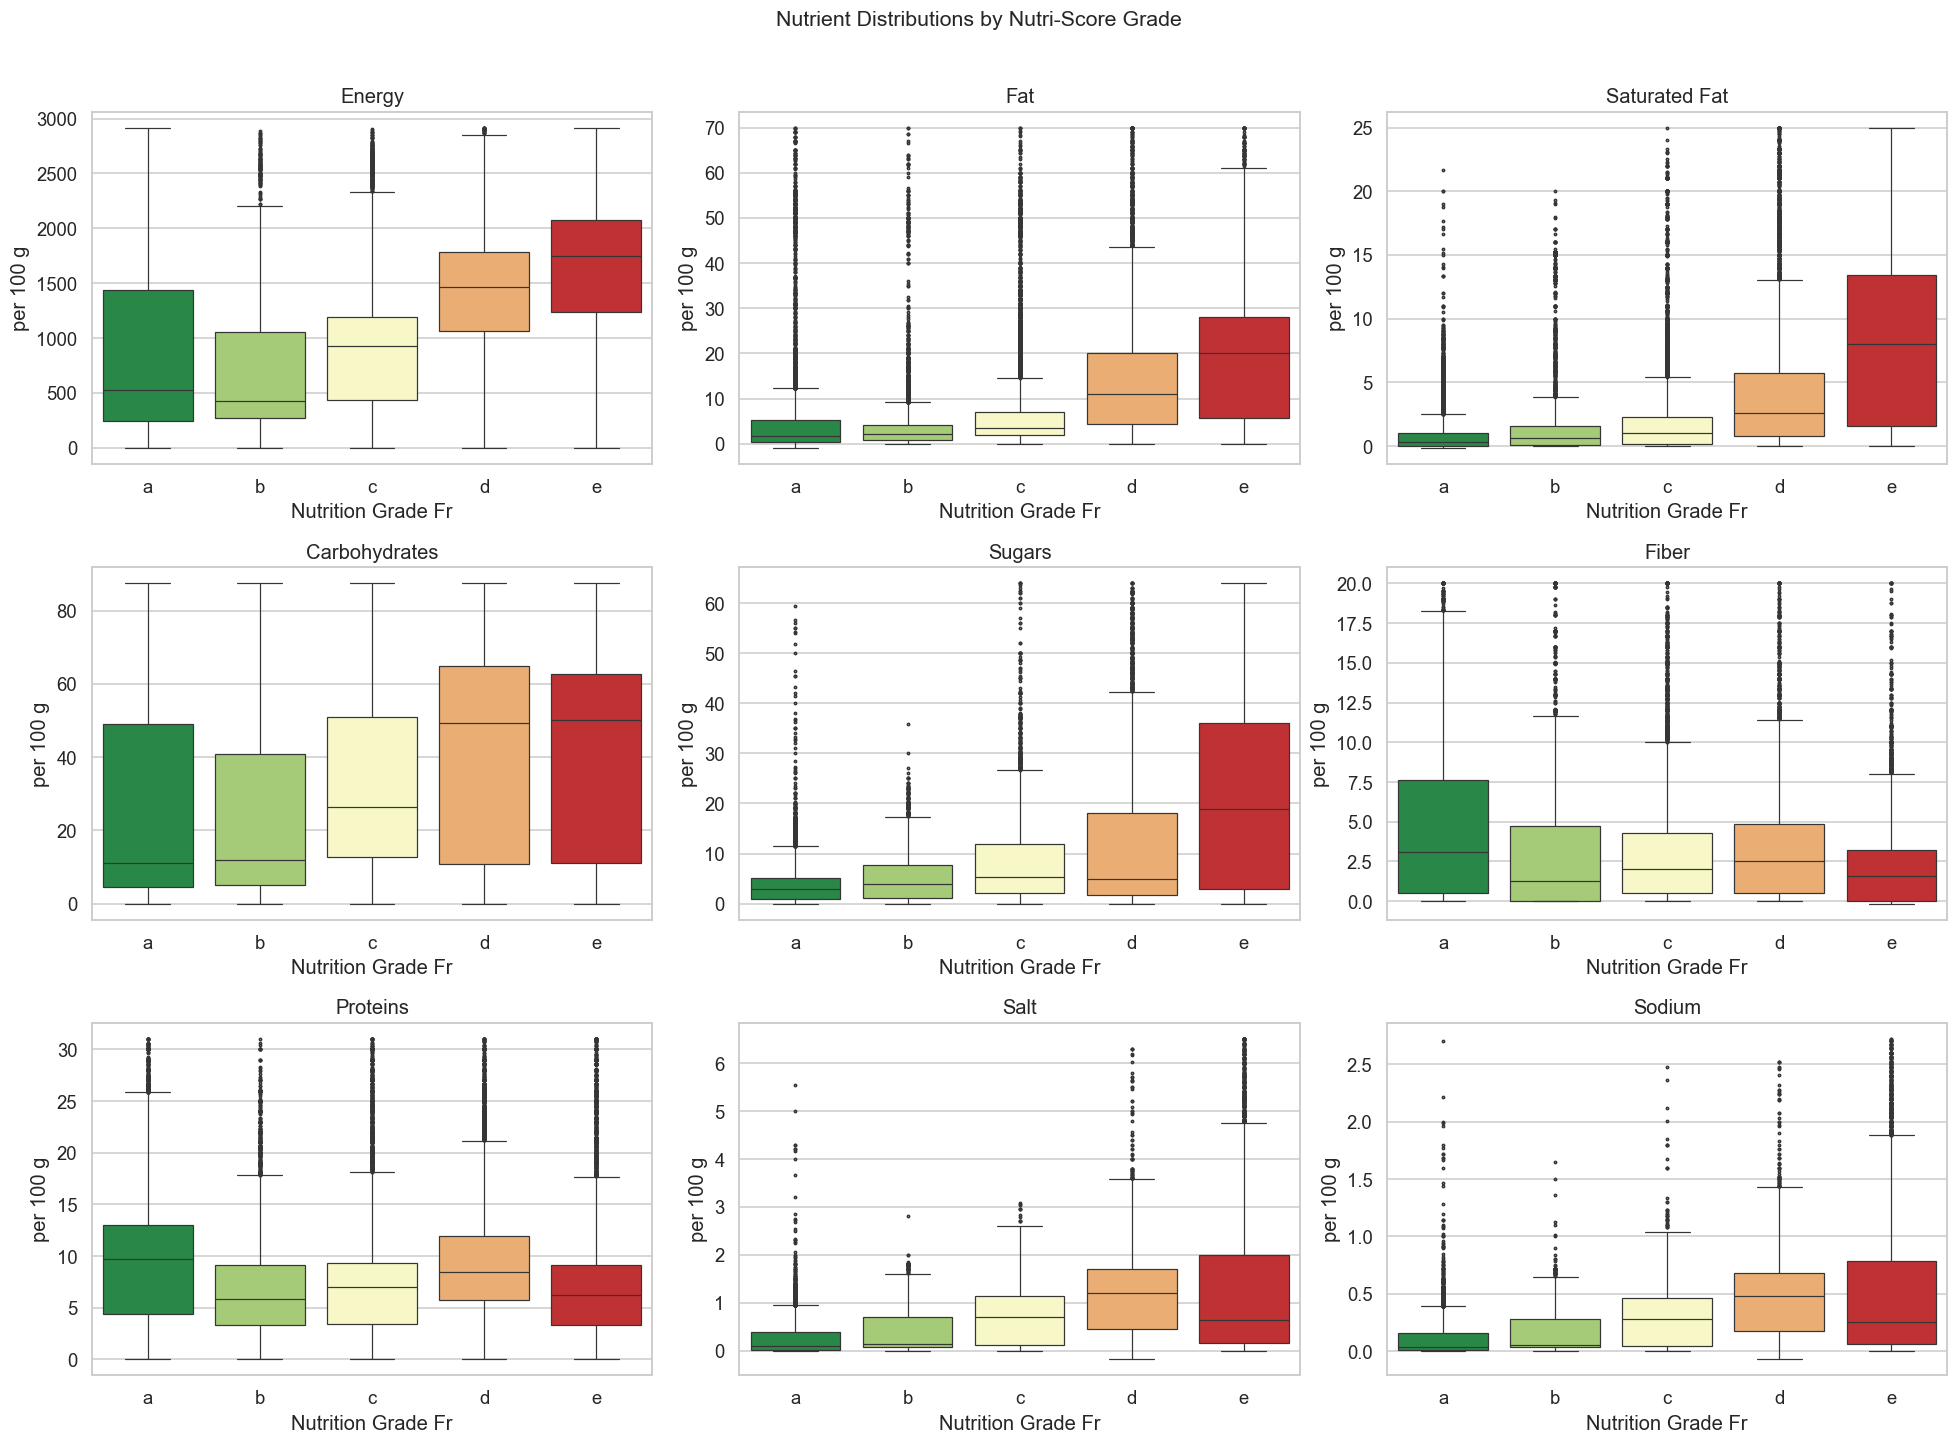

In [37]:
plotter.plot_nutrients_by_group(
    df,
    NUTRIENT_COLS,
    group_col="nutrition_grade_fr",
    order=GRADE_ORDER,
    palette=plotter.grade_palette,
    title="Nutrient Distributions by Nutri-Score Grade",
)

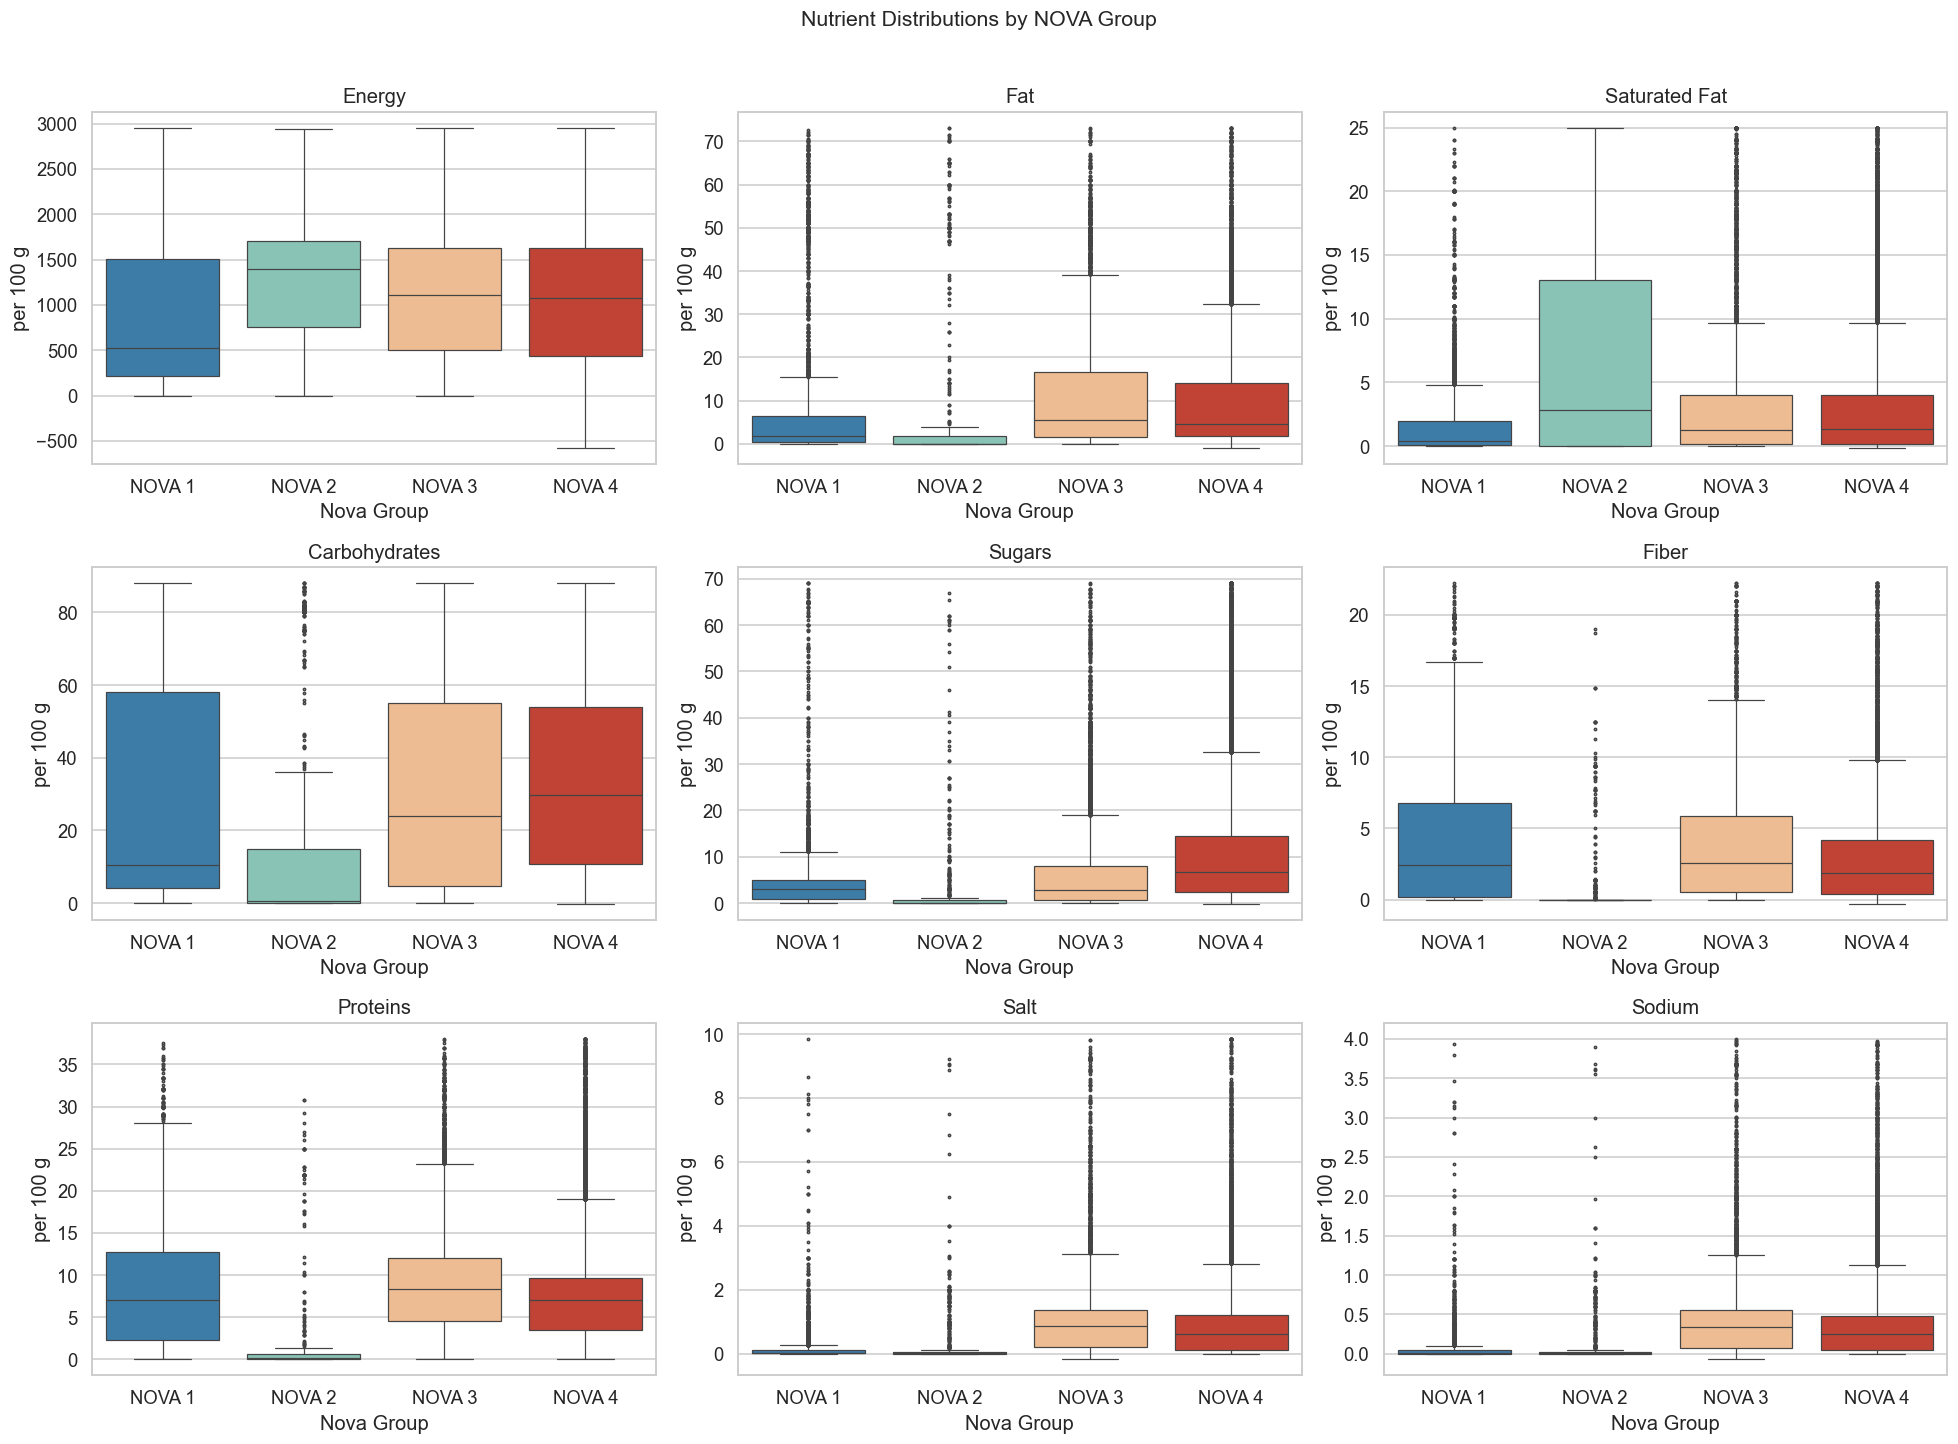

In [38]:
plotter.plot_nutrients_by_group(
    df,
    NUTRIENT_COLS,
    group_col="nova_group",
    order=NOVA_ORDER,
    palette=plotter.nova_palette,
    title="Nutrient Distributions by NOVA Group",
)

## 6. Correlation and Multicollinearity Analysis

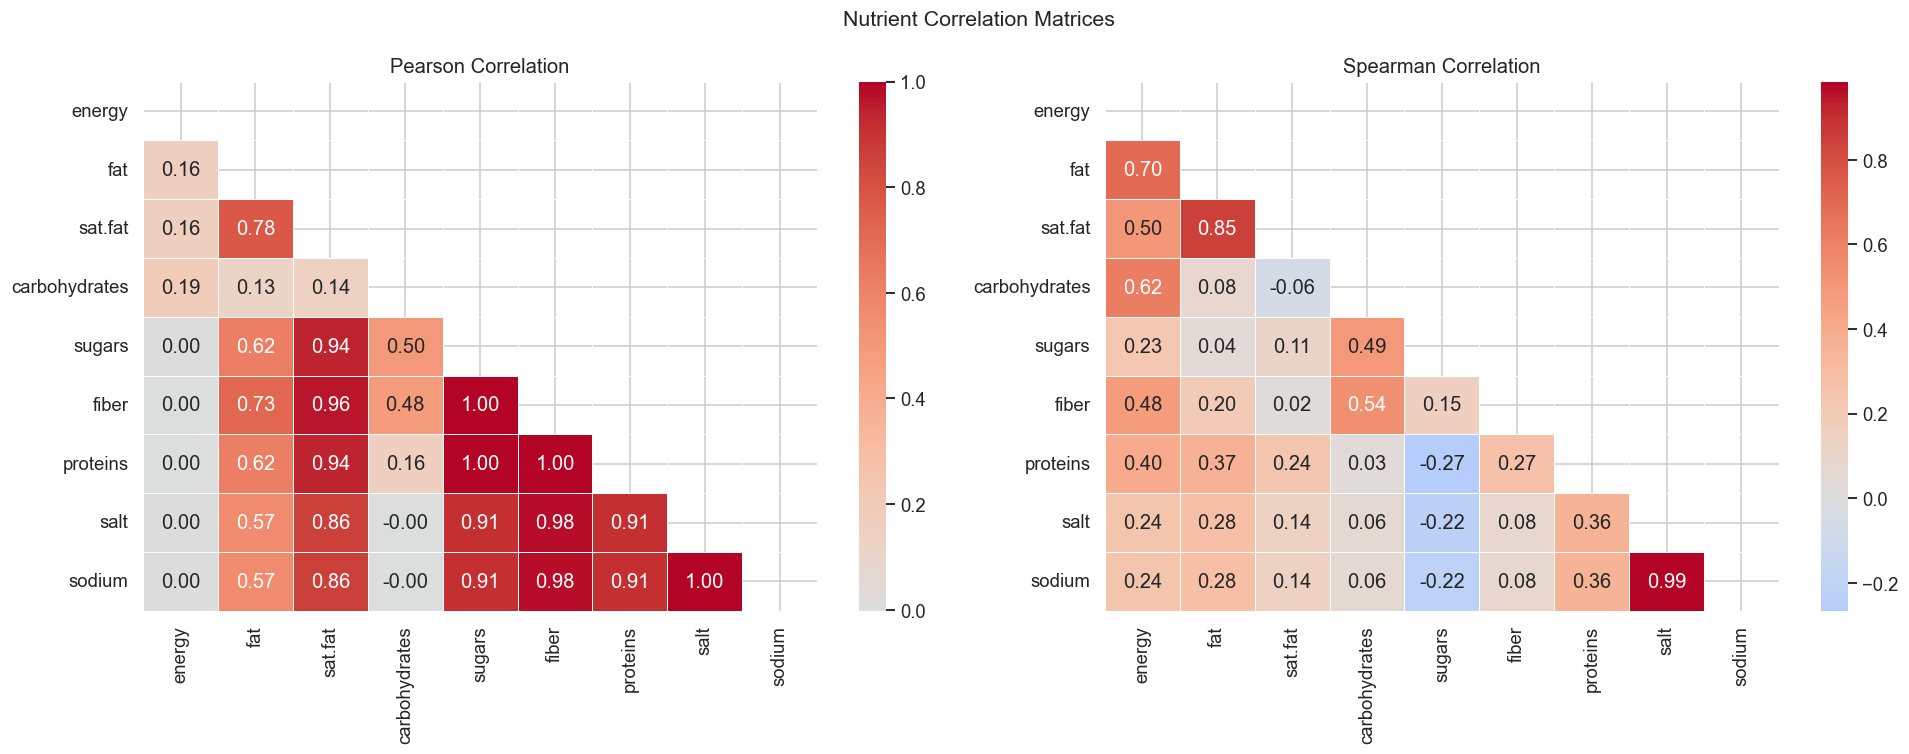

,Feature A,Feature B,Pearson r
0,saturated-fat_100g,sugars_100g,0.944
1,saturated-fat_100g,fiber_100g,0.964
2,saturated-fat_100g,proteins_100g,0.943
3,saturated-fat_100g,salt_100g,0.863
4,saturated-fat_100g,sodium_100g,0.863
5,sugars_100g,fiber_100g,1.000
6,sugars_100g,proteins_100g,1.000
7,sugars_100g,salt_100g,0.913
8,sugars_100g,sodium_100g,0.913
9,fiber_100g,proteins_100g,1.000


In [39]:
nutrient_data = df[NUTRIENT_COLS].dropna(how="all")
pearson, spearman, high_corr_df = compute_high_correlation_pairs(
    nutrient_data,
    NUTRIENT_COLS,
)

plotter.plot_correlation_matrices(pearson, spearman, NUTRIENT_COLS)

if high_corr_df.empty:
    print("No pairs exceed |r| = 0.85.")
else:
    display(high_corr_df)

## 7. Additive and Ingredient Analysis

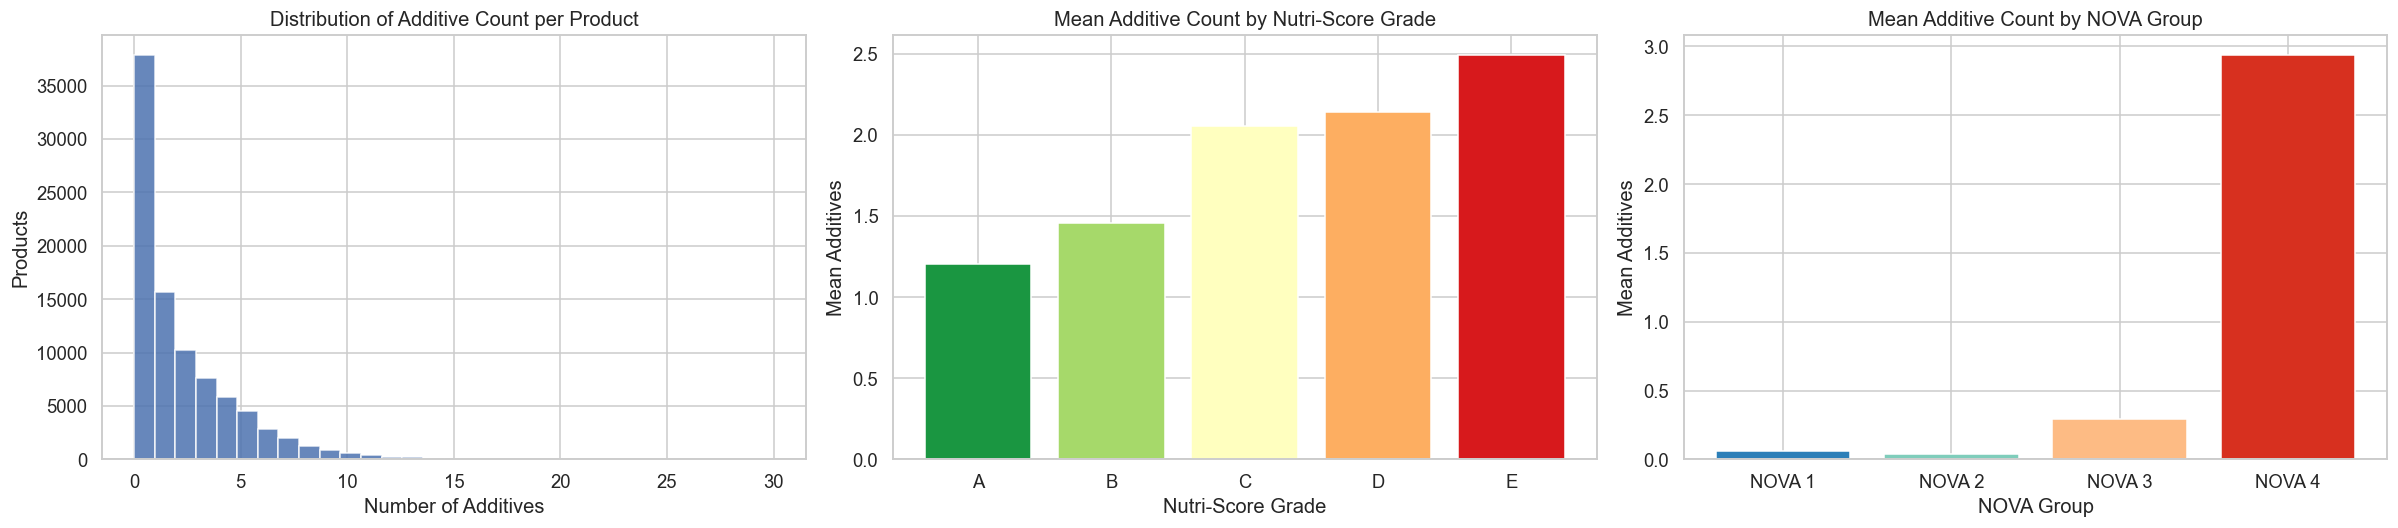

In [40]:
plotter.plot_additives_overview(df)

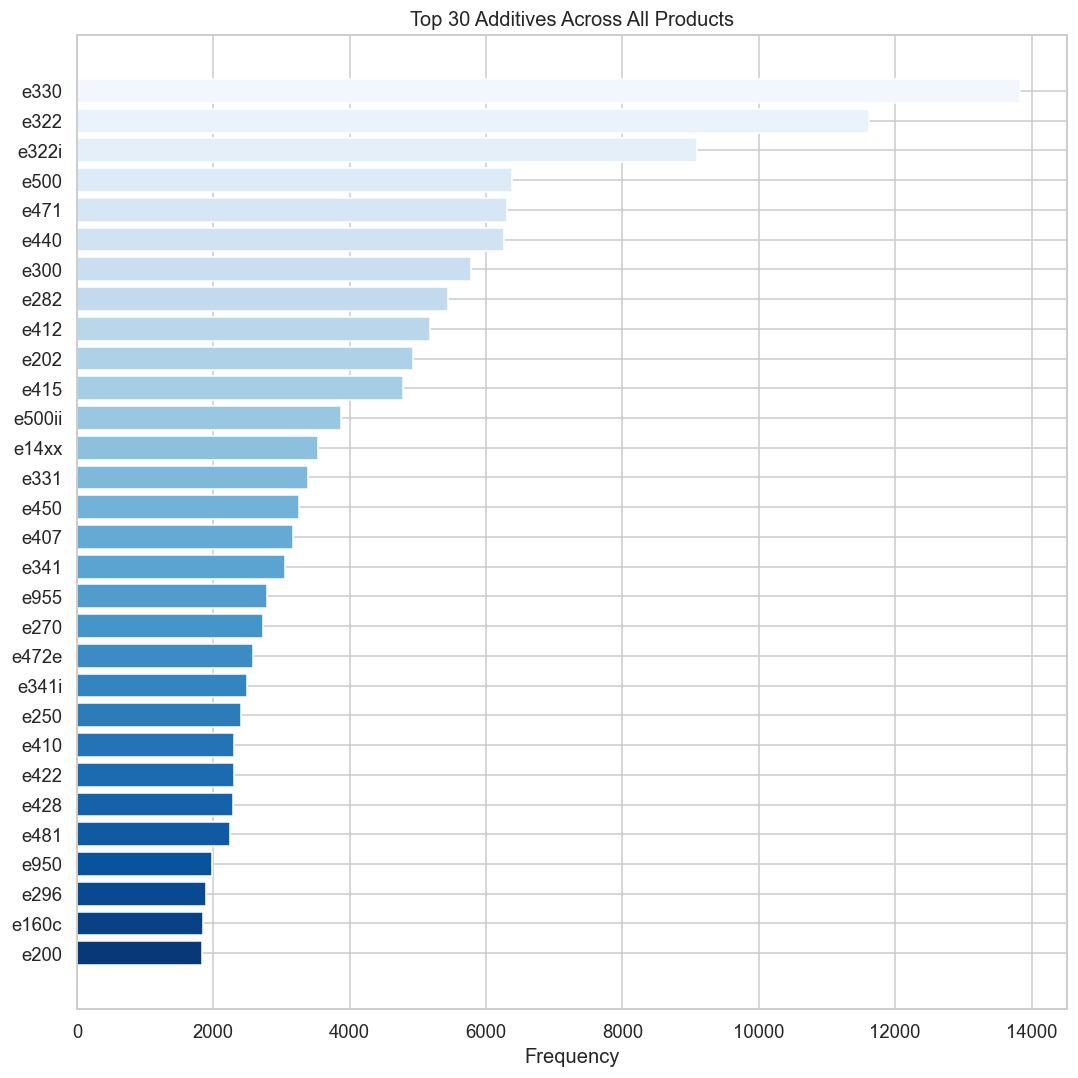

In [41]:
plotter.plot_top_additives(df)

## 8. Feature Relationships with Nutritional Quality and Processing Level


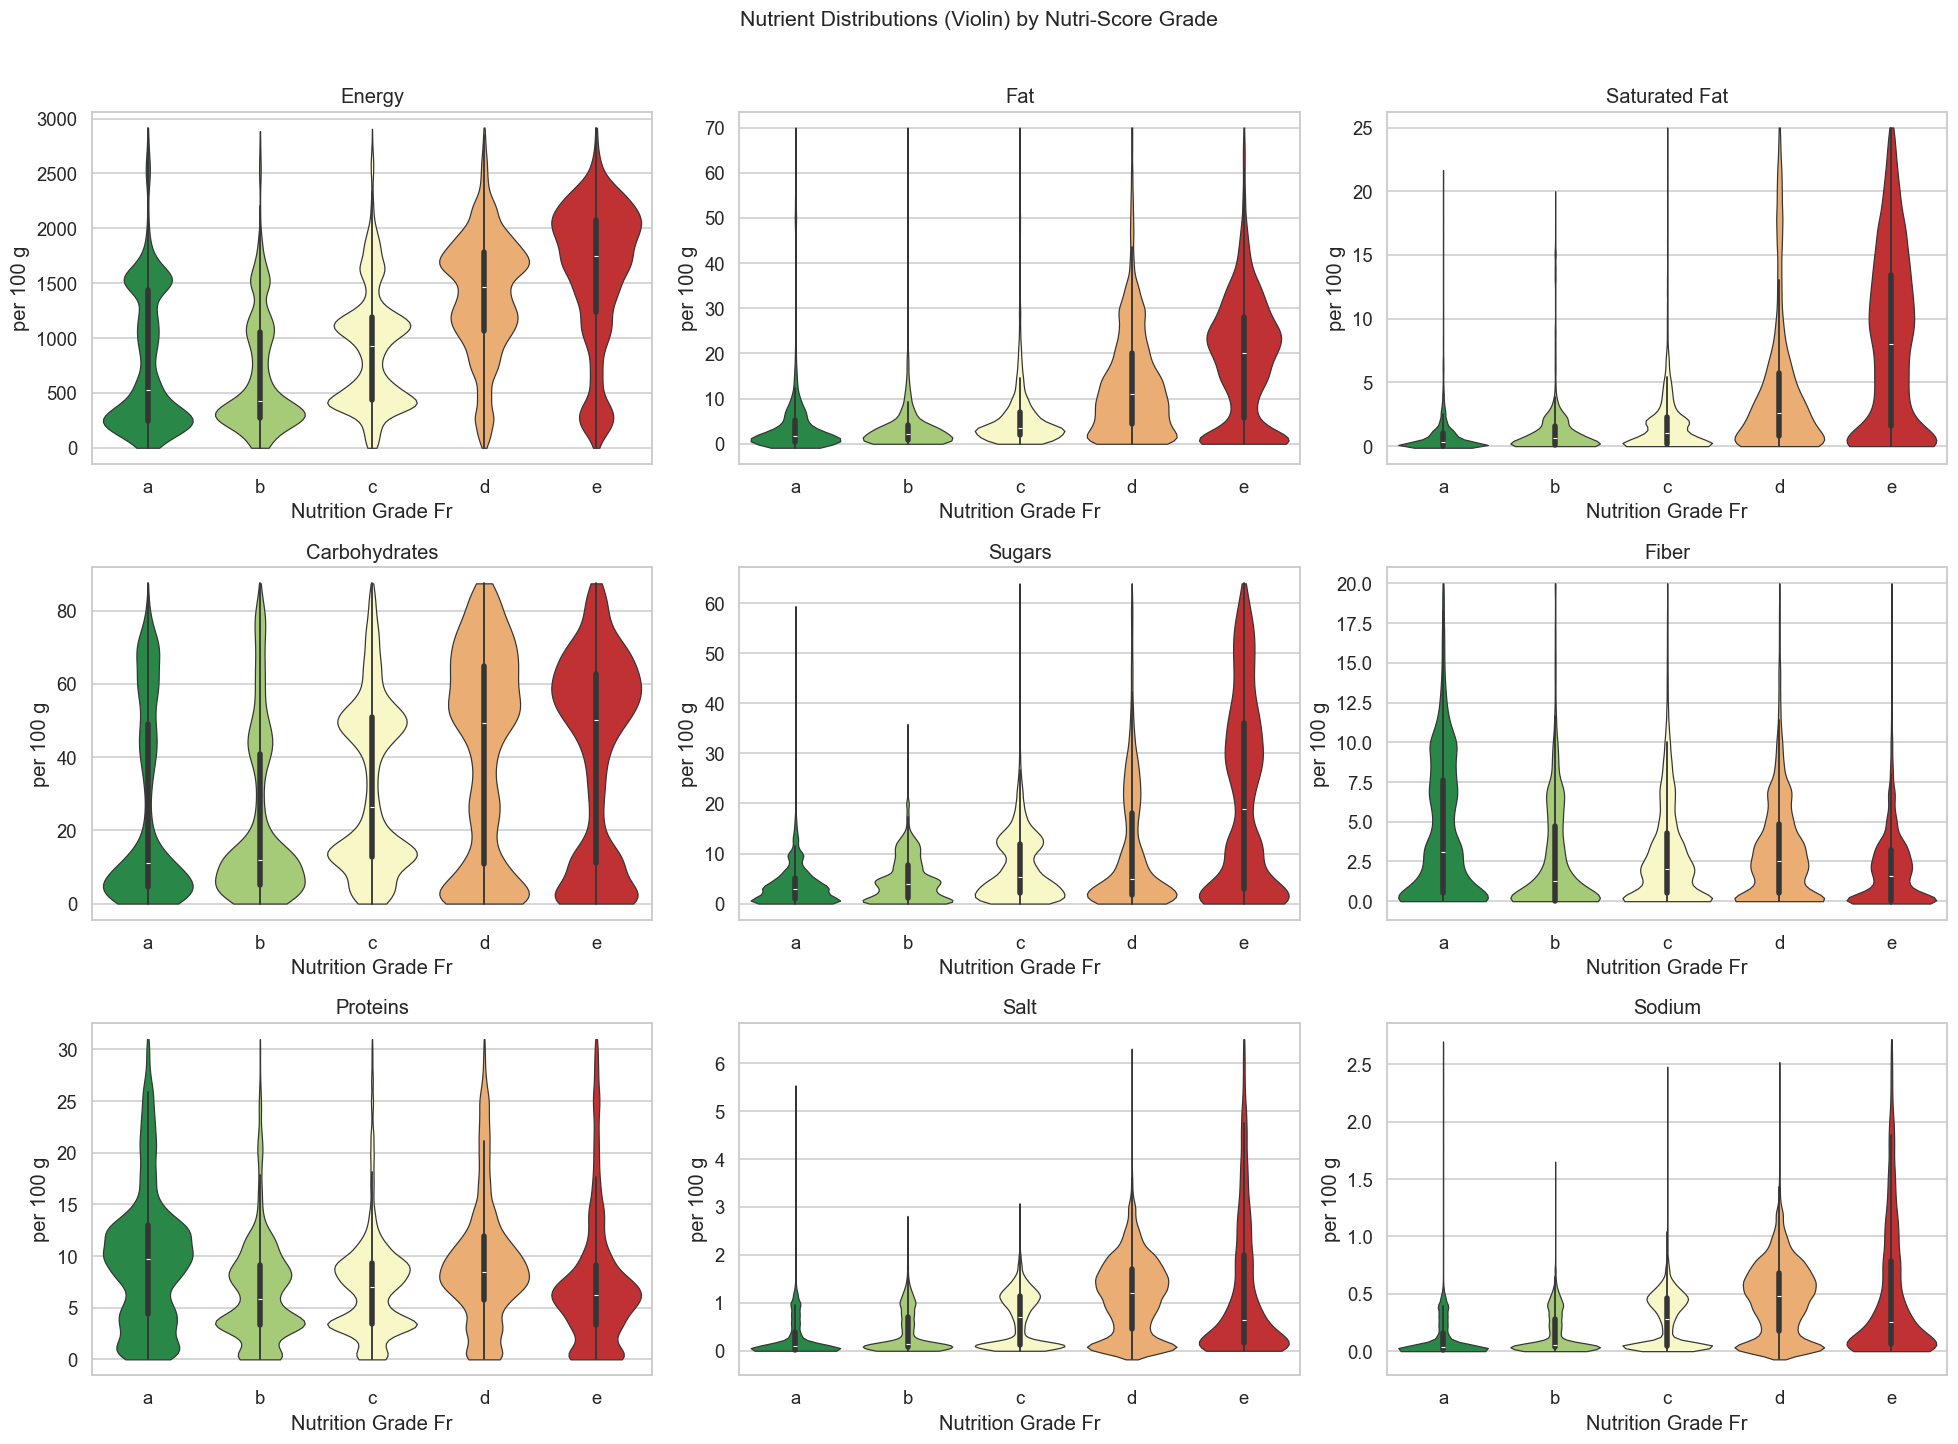

In [42]:
plotter.plot_nutrients_by_group(
    df,
    NUTRIENT_COLS,
    group_col="nutrition_grade_fr",
    order=GRADE_ORDER,
    palette=plotter.grade_palette,
    title="Nutrient Distributions (Violin) by Nutri-Score Grade",
    chart="violin",
)

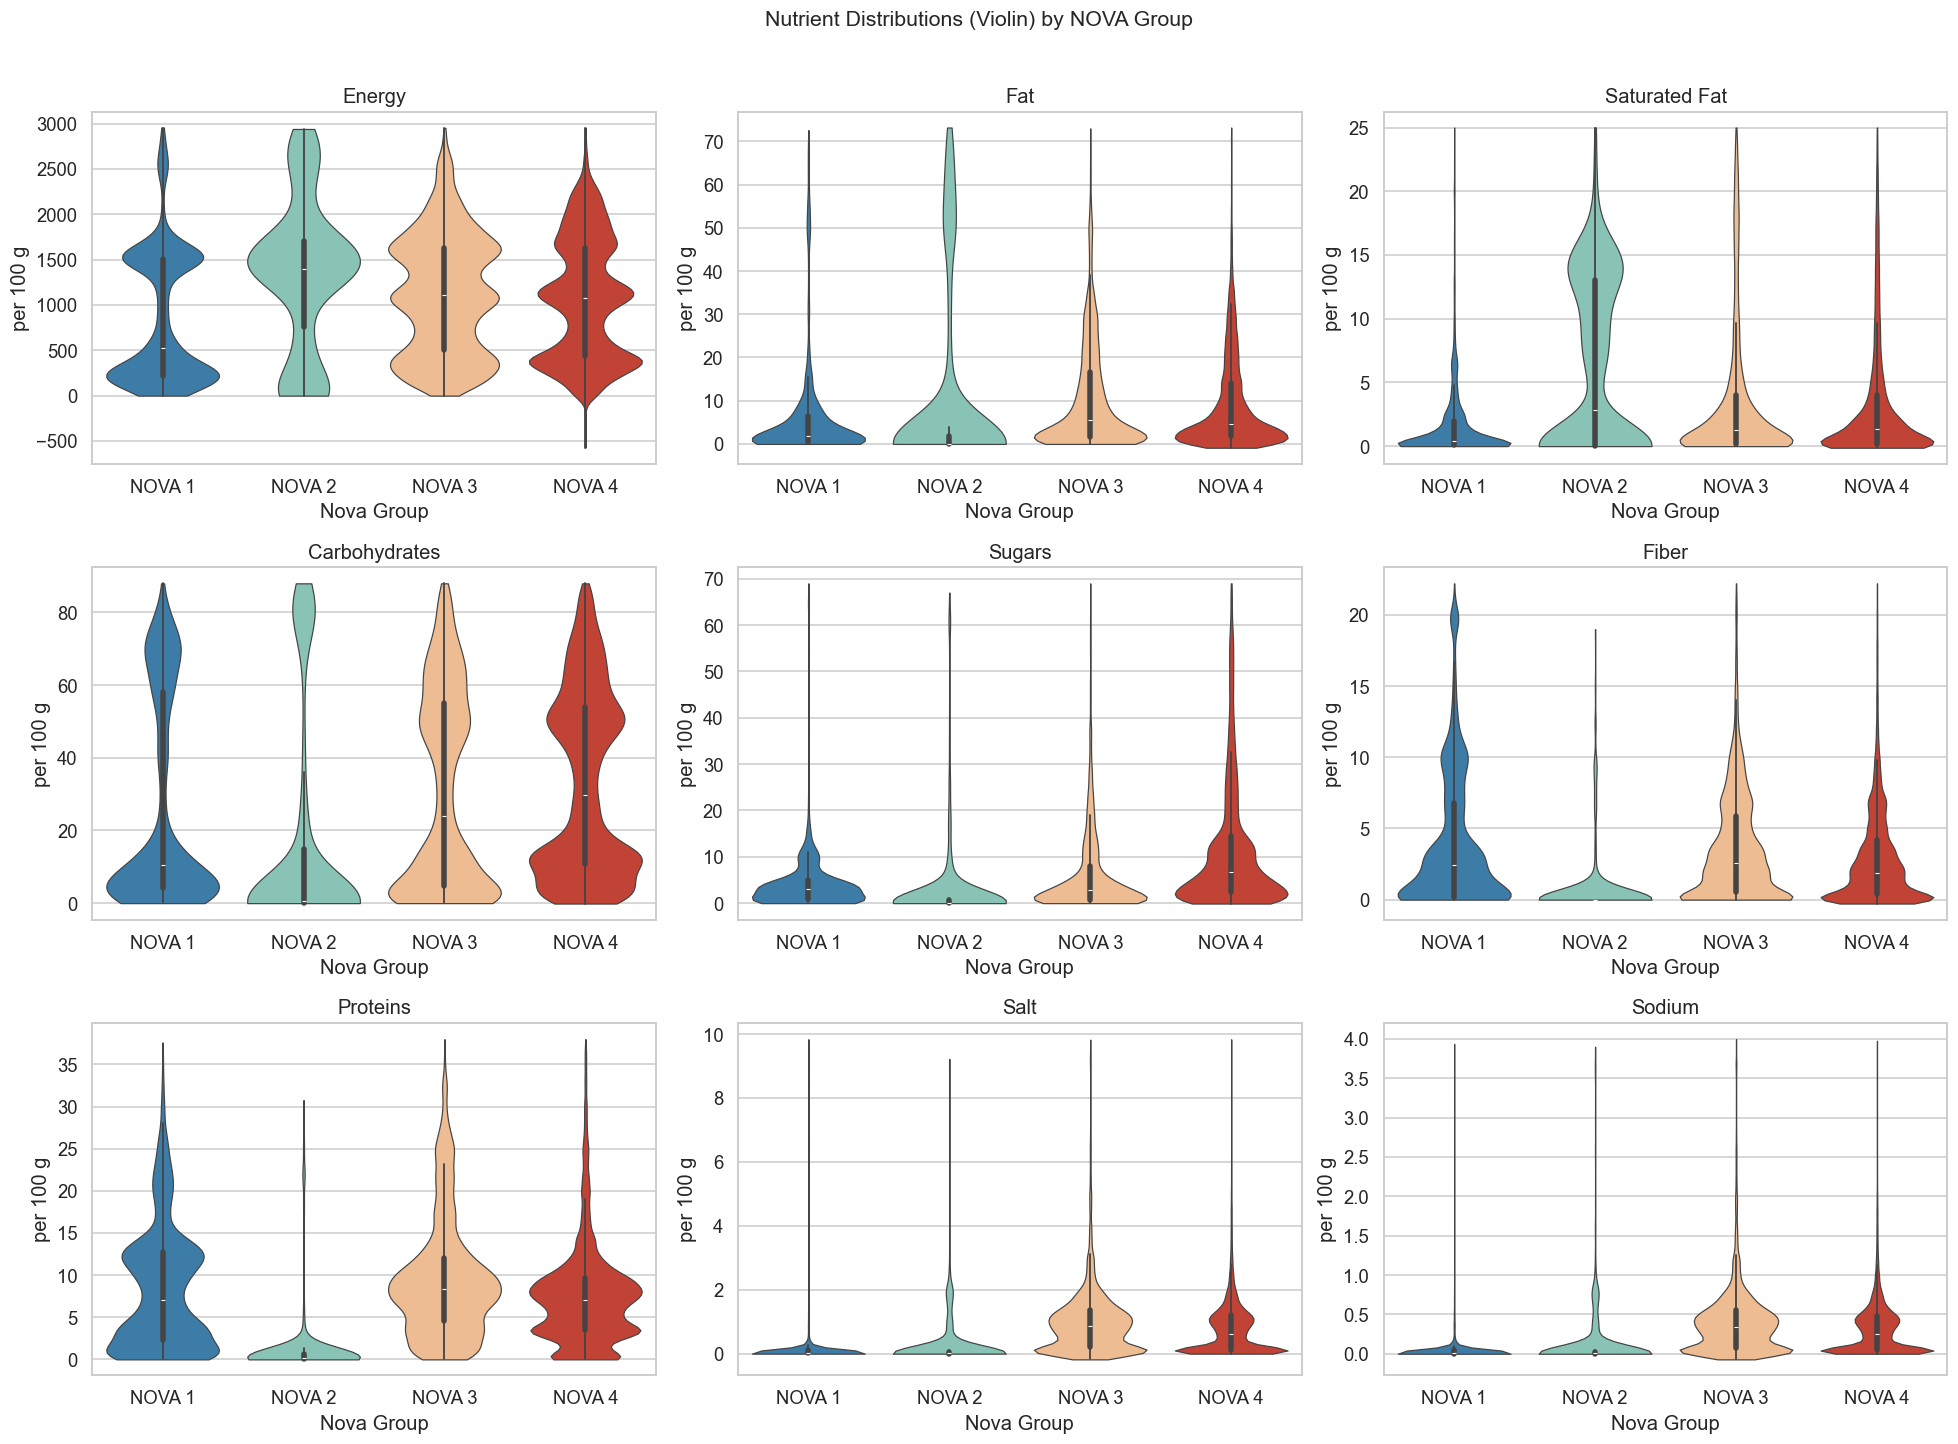

In [43]:
plotter.plot_nutrients_by_group(
    df,
    NUTRIENT_COLS,
    group_col="nova_group",
    order=NOVA_ORDER,
    palette=plotter.nova_palette,
    title="Nutrient Distributions (Violin) by NOVA Group",
    chart="violin",
)

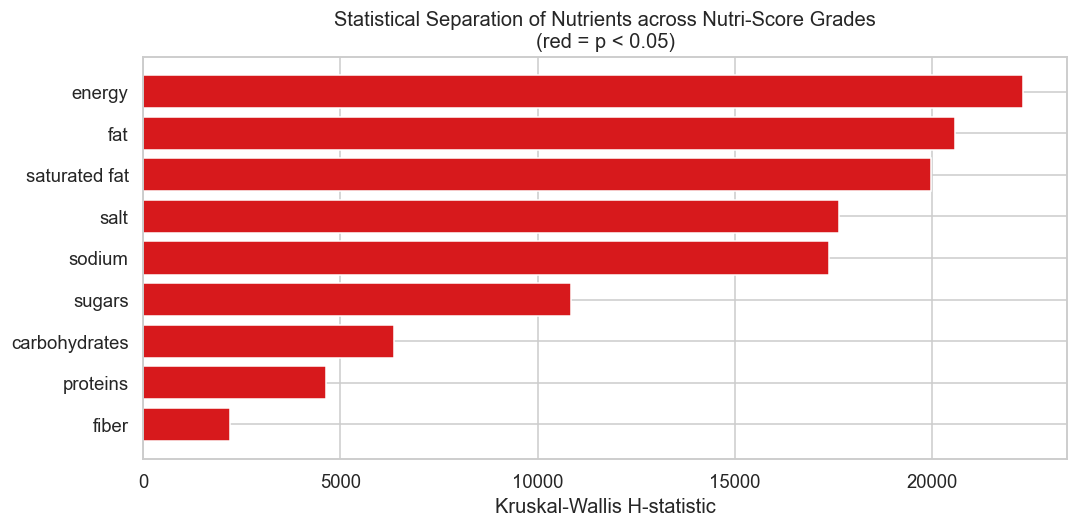

,feature,H-statistic,p-value
0,energy_100g,22311.100,0.000
1,fat_100g,20574.900,0.000
2,saturated-fat_100g,19962.800,0.000
7,salt_100g,17640.600,0.000
8,sodium_100g,17377.700,0.000
4,sugars_100g,10832.300,0.000
3,carbohydrates_100g,6351.100,0.000
6,proteins_100g,4629.300,0.000
5,fiber_100g,2190.800,0.000


In [44]:
kw_grade_df = compute_kruskal_summary(
    df,
    NUTRIENT_COLS,
    group_col="nutrition_grade_fr",
    group_order=GRADE_ORDER,
)
plotter.plot_kruskal_summary(
    kw_grade_df,
    "Statistical Separation of Nutrients across Nutri-Score Grades\n(red = p < 0.05)",
)
display(kw_grade_df)

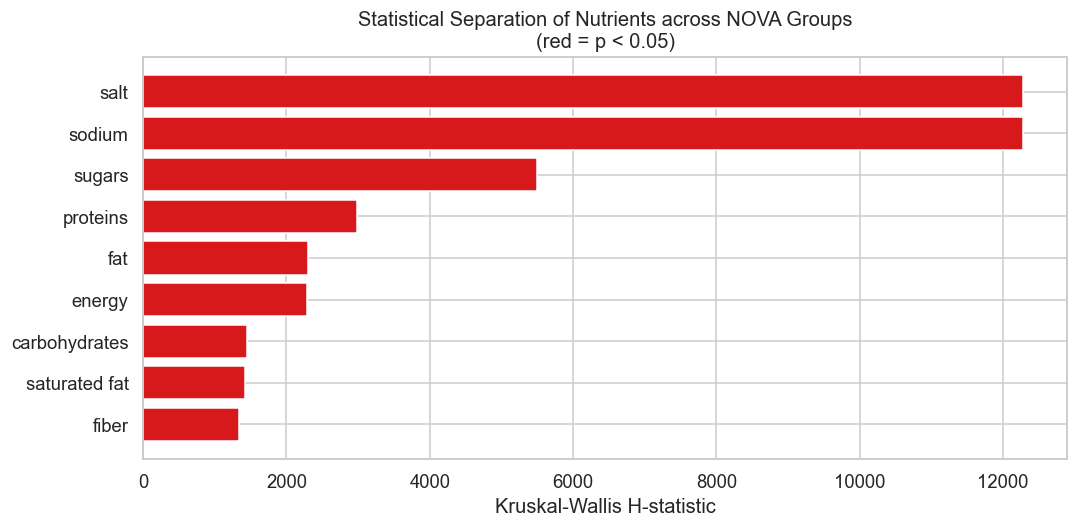

,feature,H-statistic,p-value
7,salt_100g,12283.900,0.000
8,sodium_100g,12272.000,0.000
4,sugars_100g,5492.500,0.000
6,proteins_100g,2982.800,0.000
1,fat_100g,2300.400,0.000
0,energy_100g,2282.500,0.000
3,carbohydrates_100g,1446.300,0.000
2,saturated-fat_100g,1423.300,0.000
5,fiber_100g,1338.000,0.000


In [45]:
kw_nova_df = compute_kruskal_summary(
    df,
    NUTRIENT_COLS,
    group_col="nova_group",
    group_order=NOVA_ORDER,
)
plotter.plot_kruskal_summary(
    kw_nova_df,
    "Statistical Separation of Nutrients across NOVA Groups\n(red = p < 0.05)",
)
display(kw_nova_df)

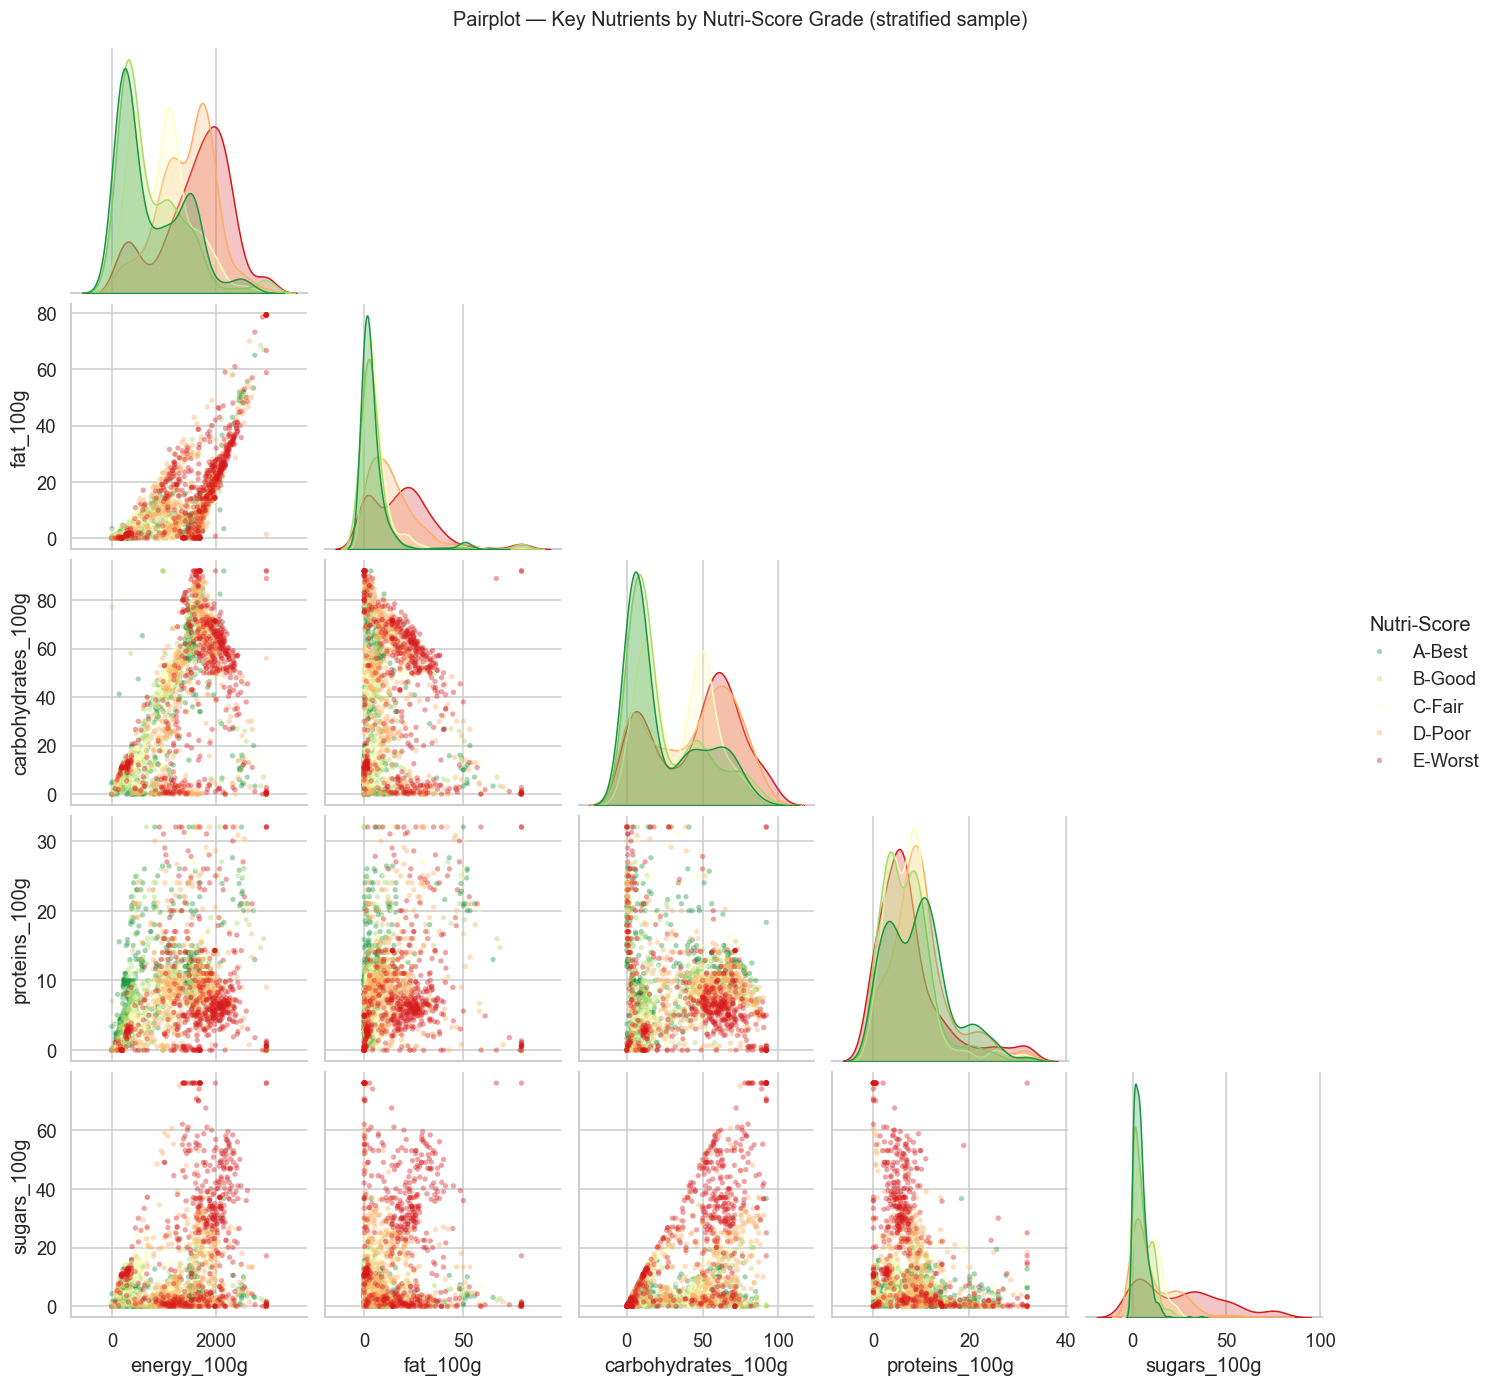

In [46]:
plotter.plot_pairplot(df)

## 9. Outlier Detection

,feature,outliers,outlier_pct
8,sodium_100g,508,0.370
7,salt_100g,500,0.360
5,fiber_100g,118,0.110
2,saturated-fat_100g,118,0.090
0,energy_100g,76,0.050
3,carbohydrates_100g,69,0.050
1,fat_100g,47,0.030
4,sugars_100g,28,0.020
6,proteins_100g,37,0.020


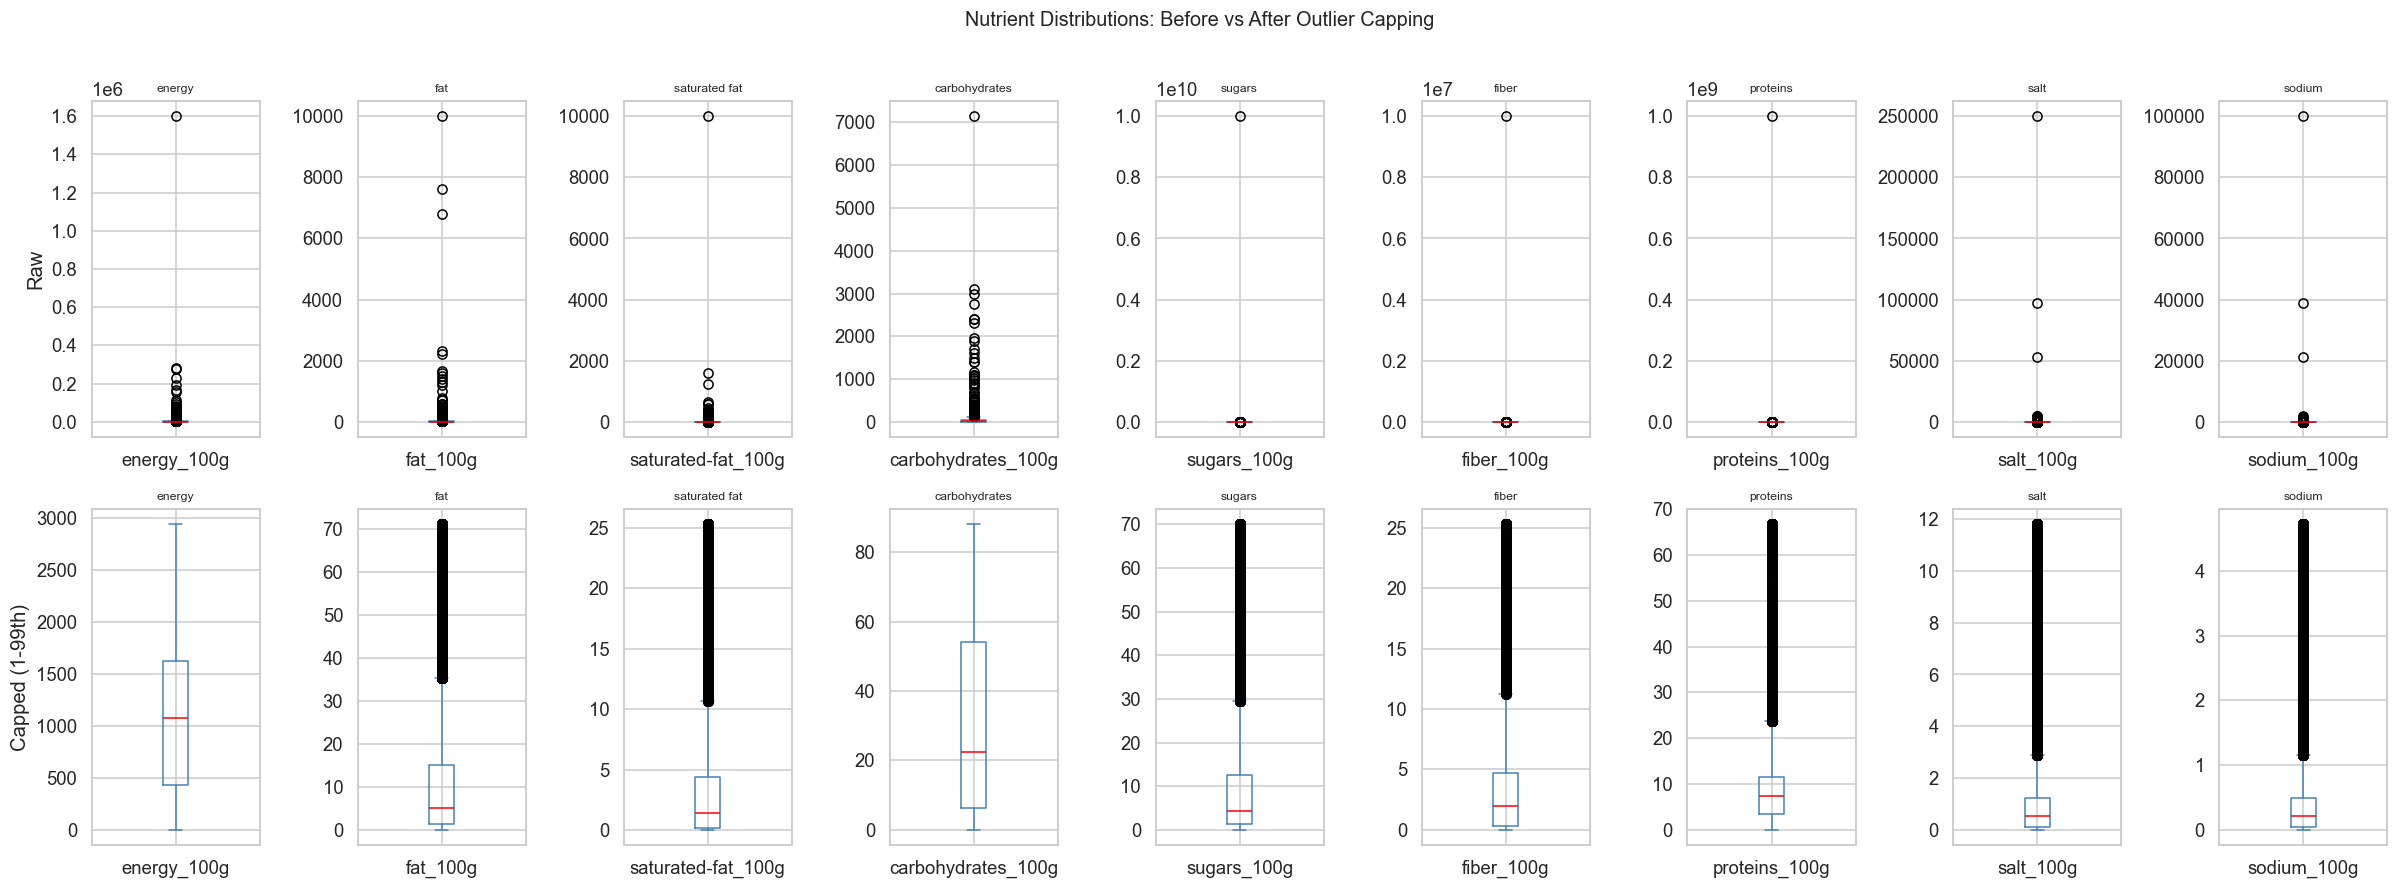

In [47]:
df_capped, out_df = cap_outliers(df, NUTRIENT_COLS)
display(out_df)
plotter.plot_outlier_boxplots(df, df_capped, NUTRIENT_COLS)

## 10. Missing Data Imputation Strategy

Imputation Summary


,feature,global_median,strategy
0,energy_100g,1072.500,global median
1,fat_100g,5.000,global median
2,saturated-fat_100g,1.400,global median
3,carbohydrates_100g,22.500,global median
4,sugars_100g,4.400,global median
5,fiber_100g,2.000,global median
6,proteins_100g,7.400,global median
7,salt_100g,0.550,global median
8,sodium_100g,0.220,global median


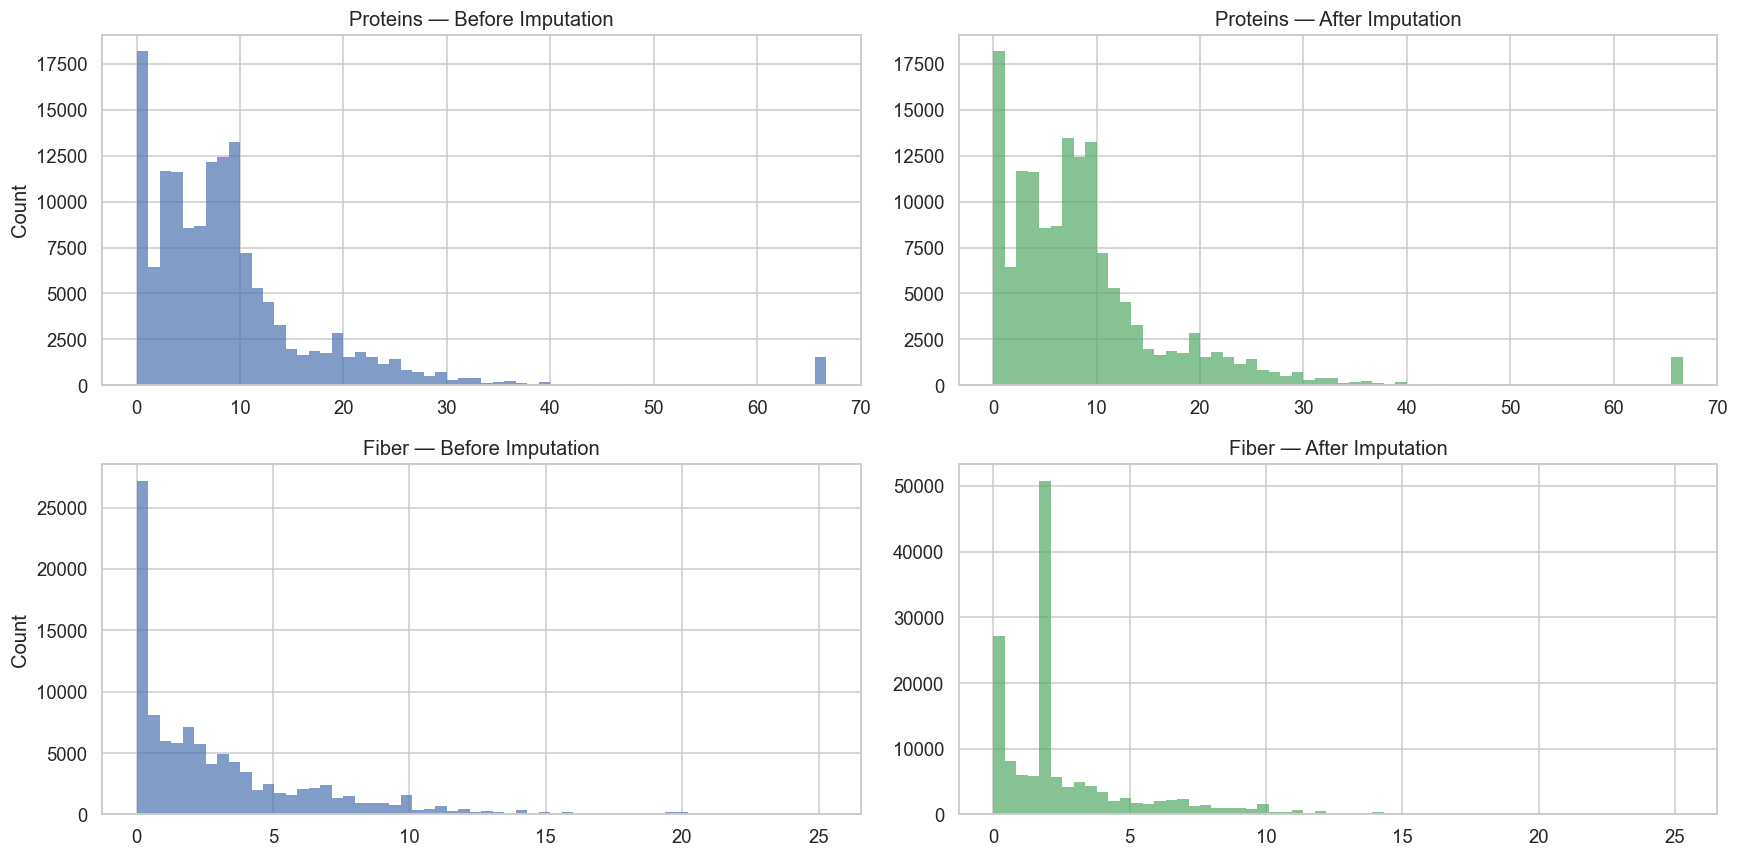

In [48]:
df_imp, imp_df = impute_with_global_median(df_capped, NUTRIENT_COLS)

print("Imputation Summary")
display(imp_df)
plotter.plot_imputation_comparison(df_capped, df_imp, COMPARE_COLS)

## 11. Geographic and Category Distribution

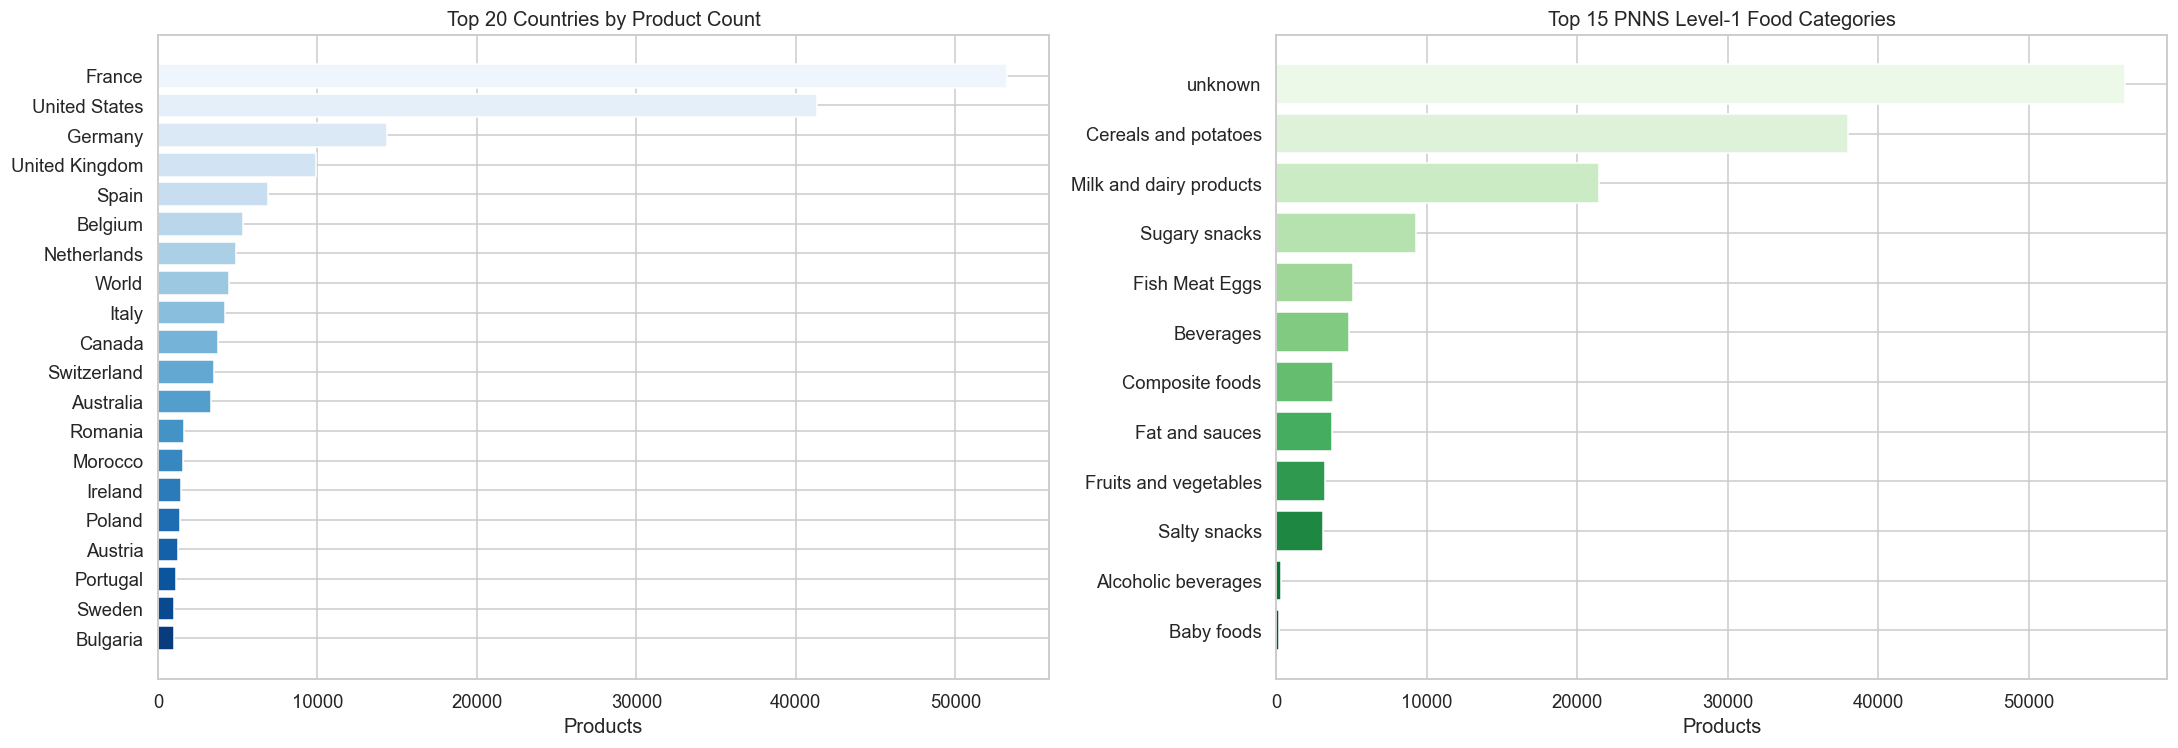

In [49]:
plotter.plot_geo_category_distribution(df)

## 12. Nutritional Profile Clustering Preview (PCA + KMeans)

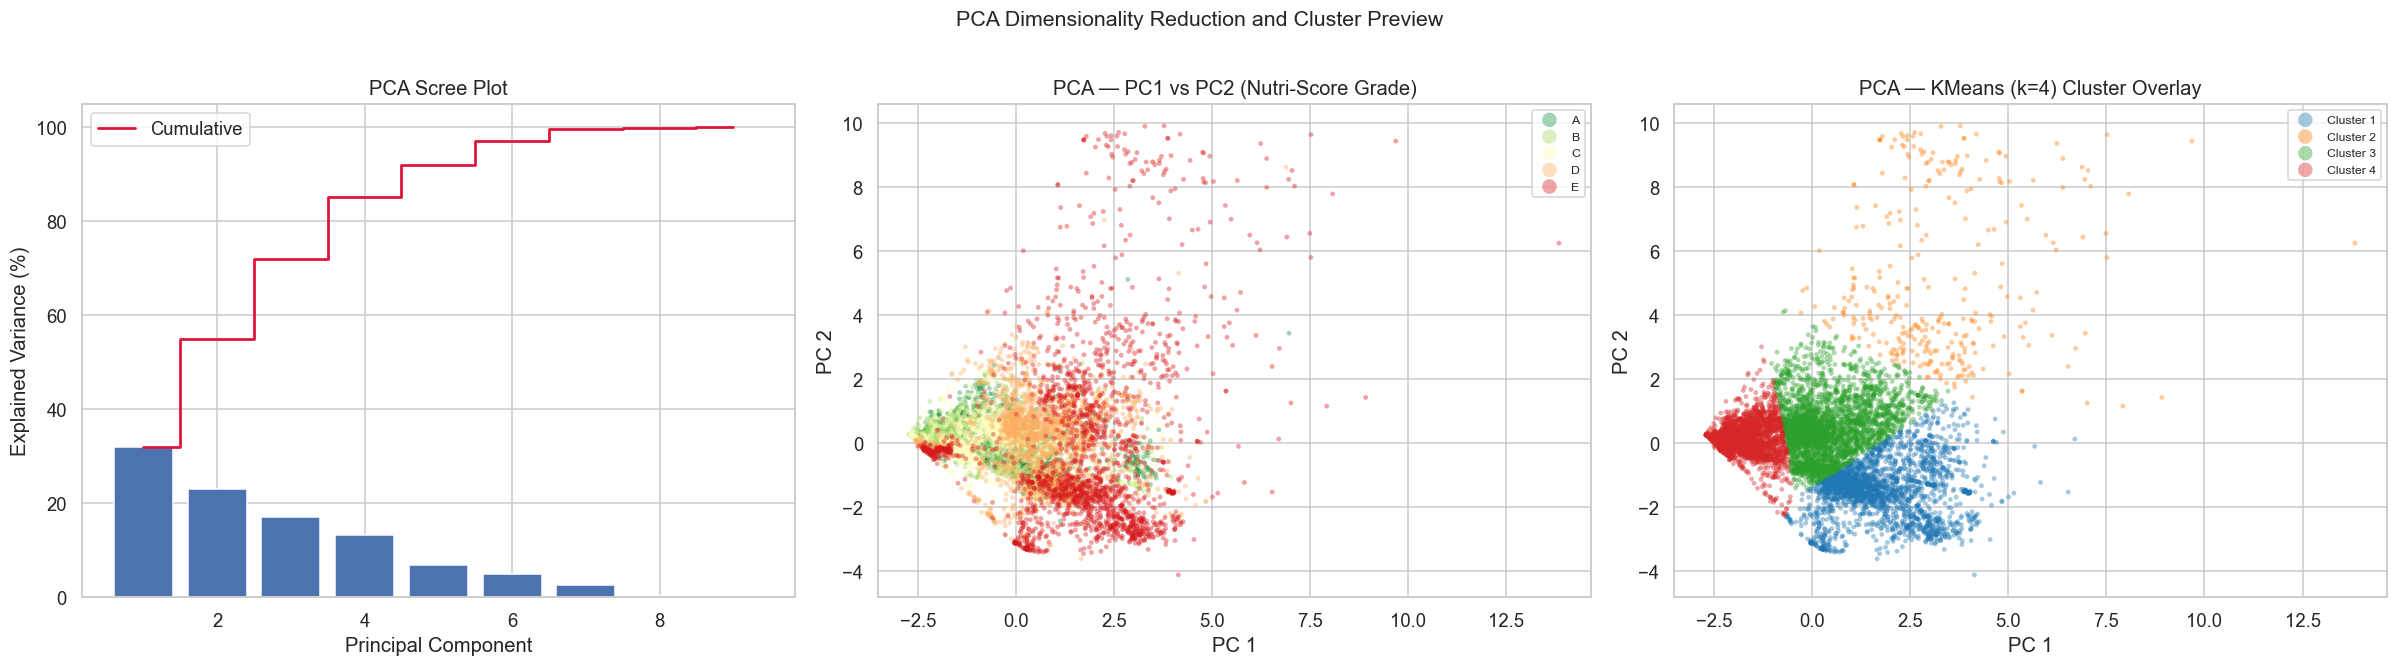

Variance explained by PC1+PC2: 54.9%


In [50]:
plotter.plot_pca_kmeans_preview(df_imp, NUTRIENT_COLS)